# 06 — Causal Inference: Media Effectiveness Analysis

## Objective
Estimate the **causal effect** of each media channel's spend on revenue,
controlling for seasonality and weather.

### Modelling Strategy
- **7 models** — total revenue + one per product category (HT, CR, SP, ME&GA, FI, BQ).
- **Ridge regression** as the primary estimator (handles multicollinearity with limited observations).
- **OLS** as a baseline; **Elastic Net** for variable-selection check.
- **Adstock + saturation** applied using calibrated parameters from NB05.
- **Bootstrap** for uncertainty quantification (1,000 resamples).
- **Robustness checks** including sensitivity to adstock/saturation assumptions.

### Data
- 36 monthly observations (FY2023-FY2025)
- 7 media channels, 6 product categories
- Controls: Fourier seasonality (2 harmonics) + 3 weather features (Greater Montreal Area)
- No holiday features (redundant with seasonality)

### Key Deliverable
A per-product effectiveness table: which media channels drive which product categories, and at what cost per incremental revenue dollar.

---
## Section 0 — Setup & Data Loading

In [1]:
# ---------- imports ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, json

from sklearn.linear_model import Ridge, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

# ---------- plot settings ----------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 10,
                      'figure.dpi': 120, 'savefig.bbox': 'tight'})
sns.set_palette('husl')

# ---------- paths ----------
project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path   = project_root / 'reports' / 'figures'
figures_path.mkdir(parents=True, exist_ok=True)

# ---------- transformation functions ----------
import sys
sys.path.append(str(project_root))
from src.features.transformations import (
    geometric_adstock, hill_saturation, hill_derivative,
    log_saturation, power_saturation
)

print(f'Project root : {project_root}')
print(f'Processed    : {processed_path}')
print(f'Figures      : {figures_path}')

Project root : /Users/raoul/Dev/busa693-clubpiscine
Processed    : /Users/raoul/Dev/busa693-clubpiscine/data/processed
Figures      : /Users/raoul/Dev/busa693-clubpiscine/reports/figures


In [2]:
# ---------- load data ----------
df_raw = pd.read_pickle(processed_path / 'sales_spend_weather.pkl')
df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f'Shape : {df_raw.shape}')
print(f'Date range : {df_raw["date"].min().date()} -- {df_raw["date"].max().date()}')
print(f'Fiscal years: {sorted(df_raw["year"].unique())}')
print(f'\nRevenue summary (3 years):')
for col in ['total_all_revenue', 'piscines_hors_terre_revenue', 'piscines_creusees_revenue',
            'spas_revenue', 'meubles_gazebo_revenue', 'fitness_revenue', 'bbq_revenue']:
    s = df_raw[col]
    print(f'  {col:35s}  total=${s.sum():>14,.0f}  mean=${s.mean():>12,.0f}')

Shape : (36, 43)
Date range : 2022-11-01 -- 2025-10-01
Fiscal years: [np.int64(2023), np.int64(2024), np.int64(2025)]

Revenue summary (3 years):
  total_all_revenue                    total=$   512,411,602  mean=$  14,233,656
  piscines_hors_terre_revenue          total=$   124,370,774  mean=$   3,454,744
  piscines_creusees_revenue            total=$    45,737,730  mean=$   1,270,492
  spas_revenue                         total=$   134,825,940  mean=$   3,745,165
  meubles_gazebo_revenue               total=$   186,622,500  mean=$   5,183,958
  fitness_revenue                      total=$     8,111,496  mean=$     225,319
  bbq_revenue                          total=$    12,743,162  mean=$     353,977


---
## Section 1 — Data Preparation

1. Map 7 spend columns to media channel names.
2. Adstock transformation (geometric decay from NB05).
3. Hill saturation (from NB05).
4. Build control features (Fourier seasonality + 3 weather features).

In [3]:
# ===================================================================
# 1-A  CHANNEL MAPPING  (spend_ -> media_)
# ===================================================================

df = df_raw.copy()

SPEND_TO_MEDIA = {
    'media_television':          'spend_television',
    'media_radio':               'spend_radio',
    'media_panneaux':            'spend_panneaux',
    'media_social_media':        'spend_social_media',
    'media_preroll':             'spend_preroll',
    'media_banniere_web':        'spend_banniere_web',
    'media_circulaire_digitale': 'spend_circulaire_digitale',
}

MEDIA_CHANNELS = []
for media_col, spend_col in SPEND_TO_MEDIA.items():
    df[media_col] = df[spend_col].fillna(0)
    MEDIA_CHANNELS.append(media_col)

df['media_total'] = df[MEDIA_CHANNELS].sum(axis=1)

print('Channel groups (7):')
for ch in MEDIA_CHANNELS:
    total = df[ch].sum()
    pct = total / df['media_total'].sum() * 100
    nz  = (df[ch] > 0).sum()
    print(f'  {ch:35s}  ${total:>12,.0f}  ({pct:5.1f}%)  non-zero: {nz}/{len(df)}')
print(f'  {"TOTAL":35s}  ${df["media_total"].sum():>12,.0f}')

Channel groups (7):
  media_television                     $   3,948,951  ( 38.5%)  non-zero: 20/36
  media_radio                          $   2,167,277  ( 21.1%)  non-zero: 23/36
  media_panneaux                       $     292,495  (  2.9%)  non-zero: 9/36
  media_social_media                   $     827,421  (  8.1%)  non-zero: 36/36
  media_preroll                        $     812,648  (  7.9%)  non-zero: 27/36
  media_banniere_web                   $   1,762,168  ( 17.2%)  non-zero: 36/36
  media_circulaire_digitale            $     446,546  (  4.4%)  non-zero: 20/36
  TOTAL                                $  10,257,505


In [4]:
# ===================================================================
# 1-B  ADSTOCK TRANSFORMATION  (geometric decay from NB05)
# ===================================================================

params_path = processed_path / 'optimal_transformation_params.json'
with open(params_path) as f:
    CAUSAL_PARAMS = json.load(f)

DECAY_RATES = CAUSAL_PARAMS['decay_rates']

print(f'Parameters loaded from: {params_path.name}')
print(f'Calibration method: {CAUSAL_PARAMS["calibration_method"]}')
print(f'Calibration date: {CAUSAL_PARAMS["calibration_date"]}')
print(f'Target used for calibration: {CAUSAL_PARAMS.get("target_variable", "N/A")}')
print()

for ch in MEDIA_CHANNELS:
    lam = DECAY_RATES[ch]
    df[f'{ch}_adstock'] = geometric_adstock(df[ch].fillna(0).values, lam)

ADSTOCK_COLS = [f'{ch}_adstock' for ch in MEDIA_CHANNELS]

print('Adstock columns created:')
for ch in MEDIA_CHANNELS:
    lam = DECAY_RATES[ch]
    source = CAUSAL_PARAMS.get('decay_rate_sources', {}).get(ch, 'unknown')
    hl = np.log(0.5) / np.log(lam) if lam > 0 else 0
    print(f'  {ch}_adstock   lambda={lam}  half-life={hl:.1f}mo  ({source})')

Parameters loaded from: optimal_transformation_params.json
Calibration method: LOOCV_Ridge_cross_val_predict
Calibration date: 2026-02-11
Target used for calibration: N/A

Adstock columns created:
  media_television_adstock   lambda=0.1  half-life=0.3mo  (data)
  media_radio_adstock   lambda=0.5  half-life=1.0mo  (industry)
  media_panneaux_adstock   lambda=0.4  half-life=0.8mo  (industry)
  media_social_media_adstock   lambda=0.4  half-life=0.8mo  (industry)
  media_preroll_adstock   lambda=0.1  half-life=0.3mo  (data)
  media_banniere_web_adstock   lambda=0.3  half-life=0.6mo  (industry)
  media_circulaire_digitale_adstock   lambda=0.3  half-life=0.6mo  (industry)


In [5]:
# ===================================================================
# 1-C  SATURATION  (function type + params from NB05)
# ===================================================================

SATURATION_PARAMS = {}

for ch in MEDIA_CHANNELS:
    adstock_col = f'{ch}_adstock'
    sat_func_type = CAUSAL_PARAMS.get('saturation_functions', {}).get(ch, 'hill')
    sat_p = CAUSAL_PARAMS.get('saturation_params', {}).get(ch, {})

    if sat_func_type == 'hill':
        K = sat_p.get('K', None)
        if K is None:
            nz = df[adstock_col][df[adstock_col] > 0]
            K = float(nz.median()) if len(nz) > 0 else 1.0
        alpha = sat_p.get('alpha', 2)
        SATURATION_PARAMS[ch] = {'type': 'hill', 'K': K, 'alpha': alpha}
        df[f'{ch}_saturated'] = hill_saturation(df[adstock_col].values, K, alpha)

    elif sat_func_type == 'log':
        scale = sat_p.get('scale', None)
        if scale is None:
            nz = df[adstock_col][df[adstock_col] > 0]
            scale = float(nz.median()) if len(nz) > 0 else 1.0
        SATURATION_PARAMS[ch] = {'type': 'log', 'scale': scale}
        df[f'{ch}_saturated'] = log_saturation(df[adstock_col].values, scale)

    elif sat_func_type == 'power':
        beta = sat_p.get('beta', 0.5)
        SATURATION_PARAMS[ch] = {'type': 'power', 'beta': beta}
        df[f'{ch}_saturated'] = power_saturation(df[adstock_col].values, beta)

    else:
        # Default to hill
        nz = df[adstock_col][df[adstock_col] > 0]
        K = float(nz.median()) if len(nz) > 0 else 1.0
        SATURATION_PARAMS[ch] = {'type': 'hill', 'K': K, 'alpha': 2}
        df[f'{ch}_saturated'] = hill_saturation(df[adstock_col].values, K, 2)

SATURATED_COLS = [f'{ch}_saturated' for ch in MEDIA_CHANNELS]

print('Saturation parameters (from NB05):')
for ch, p in SATURATION_PARAMS.items():
    if p['type'] == 'hill':
        print(f'  {ch:35s}  hill  K=${p["K"]:>12,.0f}   alpha={p["alpha"]}')
    elif p['type'] == 'log':
        print(f'  {ch:35s}  log   scale=${p["scale"]:>12,.0f}')
    elif p['type'] == 'power':
        print(f'  {ch:35s}  power beta={p["beta"]}')

Saturation parameters (from NB05):
  media_television                     log   scale=$     127,905
  media_radio                          power beta=0.5
  media_panneaux                       power beta=0.5
  media_social_media                   power beta=0.5
  media_preroll                        hill  K=$      51,231   alpha=2
  media_banniere_web                   hill  K=$      32,834   alpha=2
  media_circulaire_digitale            power beta=0.5


In [6]:
# ===================================================================
# 1-D  CONTROL FEATURES + TARGETS
# ===================================================================

# Fourier seasonality (2 harmonics)
df['sin_1'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['cos_1'] = np.cos(2 * np.pi * df['month_num'] / 12)
df['sin_2'] = np.sin(4 * np.pi * df['month_num'] / 12)
df['cos_2'] = np.cos(4 * np.pi * df['month_num'] / 12)

# Weather: 3 strongest features only (Greater Montreal Area)
for wcol in ['total_sunshine_hours', 'total_precipitation', 'days_above_25']:
    df[f'{wcol}_scaled'] = (df[wcol] - df[wcol].mean()) / df[wcol].std()

CONTROL_COLS = ['sin_1', 'cos_1', 'sin_2', 'cos_2',
                'total_sunshine_hours_scaled', 'total_precipitation_scaled',
                'days_above_25_scaled']

# 7 targets: total + 6 product categories
TARGET_COLS = ['total_all_revenue',
               'piscines_hors_terre_revenue', 'piscines_creusees_revenue',
               'spas_revenue', 'meubles_gazebo_revenue',
               'fitness_revenue', 'bbq_revenue']

PRODUCT_LABELS = {
    'total_all_revenue':             'Total Revenue',
    'piscines_hors_terre_revenue':   'Above-Ground Pools (HT)',
    'piscines_creusees_revenue':     'In-Ground Pools (CR)',
    'spas_revenue':                  'Spas (SP)',
    'meubles_gazebo_revenue':        'Furniture & Gazebo (ME&GA)',
    'fitness_revenue':               'Fitness (FI)',
    'bbq_revenue':                   'BBQ (BQ)',
}

# Feature matrix
FEATURE_COLS = SATURATED_COLS + CONTROL_COLS

print(f'Features ({len(FEATURE_COLS)}):')
for f in FEATURE_COLS:
    print(f'  {f}')
print(f'\nTargets ({len(TARGET_COLS)}): {[PRODUCT_LABELS[t] for t in TARGET_COLS]}')
print(f'Observations: {len(df)}')

Features (14):
  media_television_saturated
  media_radio_saturated
  media_panneaux_saturated
  media_social_media_saturated
  media_preroll_saturated
  media_banniere_web_saturated
  media_circulaire_digitale_saturated
  sin_1
  cos_1
  sin_2
  cos_2
  total_sunshine_hours_scaled
  total_precipitation_scaled
  days_above_25_scaled

Targets (7): ['Total Revenue', 'Above-Ground Pools (HT)', 'In-Ground Pools (CR)', 'Spas (SP)', 'Furniture & Gazebo (ME&GA)', 'Fitness (FI)', 'BBQ (BQ)']
Observations: 36


---
## Section 2 — Identification Challenge (Pre-Modelling Diagnostics)

Why naive correlation does not equal causation in this dataset:
- **Seasonality confound** — both spending and revenue peak in spring/summer.
- **Multicollinearity** — most channels fire together (campaign bursts).
- **Small N** — 36 observations with 14 parameters is tight but workable with Ridge.

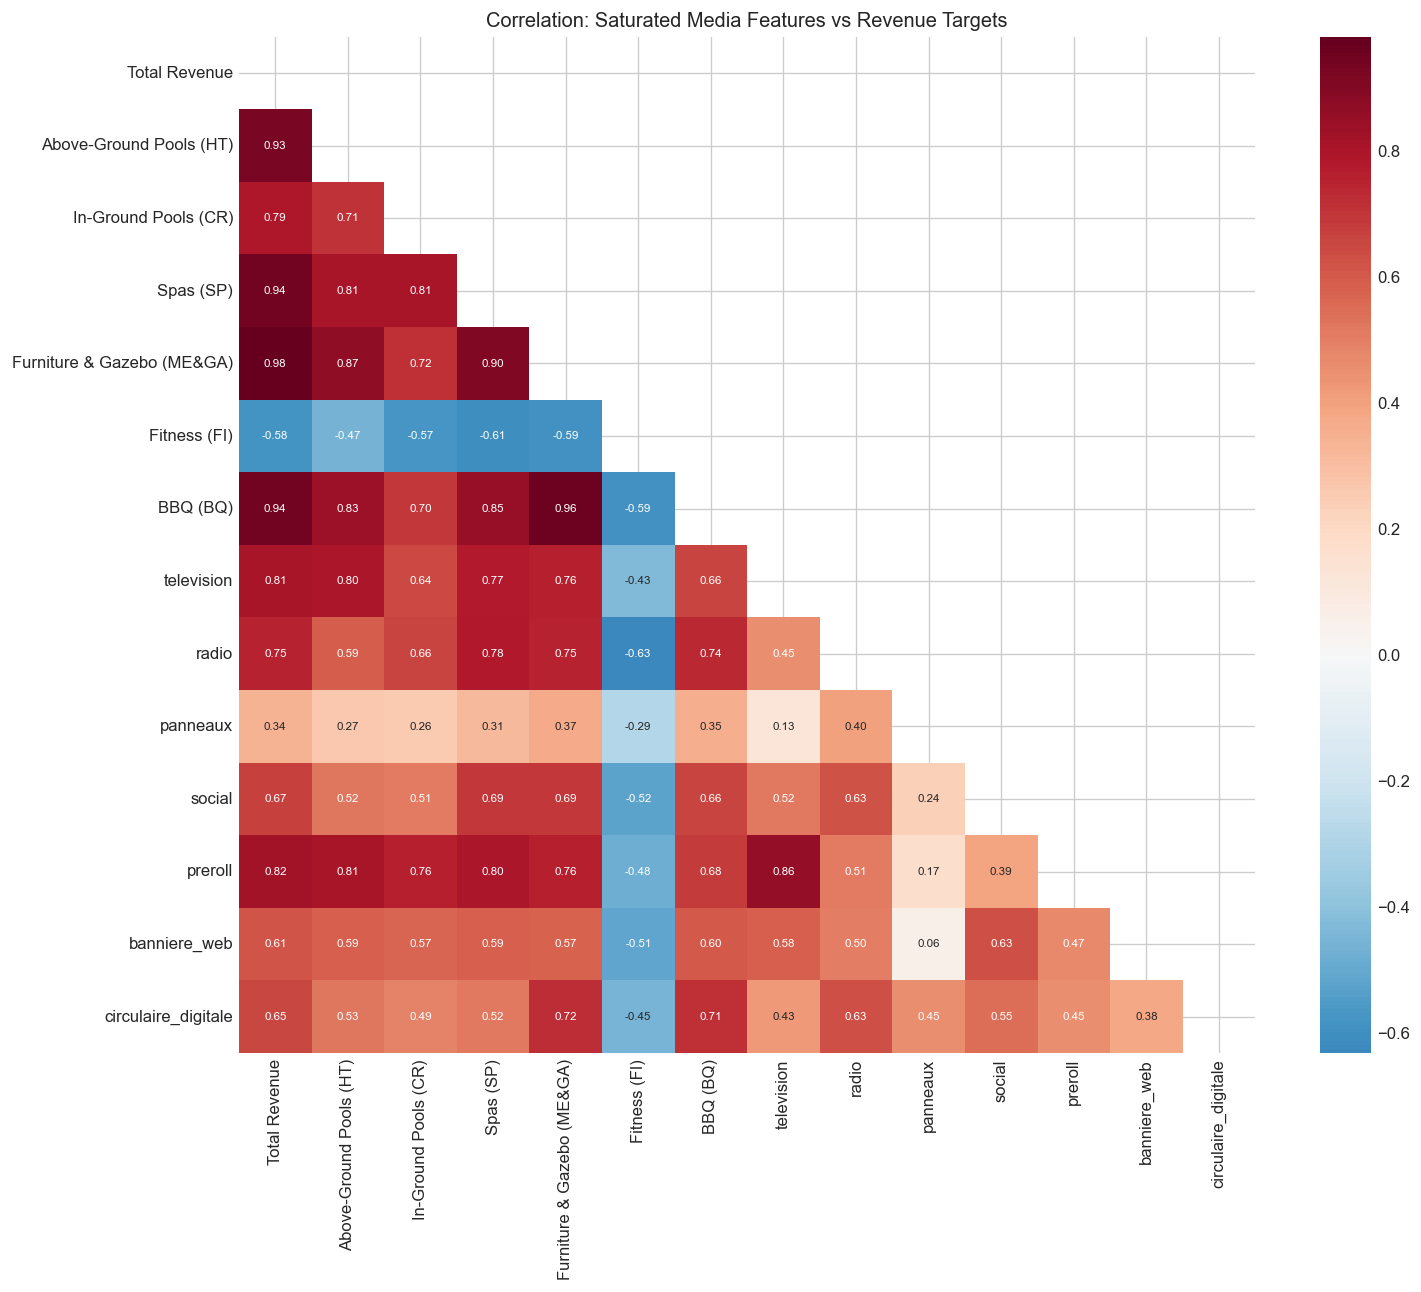

In [7]:
# ---------- Correlation matrix: saturated media + targets ----------
corr_cols = TARGET_COLS + SATURATED_COLS
corr_mat  = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
labels = [PRODUCT_LABELS.get(c, c.replace('media_', '').replace('_saturated', ''))
          for c in corr_cols]
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, xticklabels=labels, yticklabels=labels, square=True,
            annot_kws={'size': 7})
ax.set_title('Correlation: Saturated Media Features vs Revenue Targets')
plt.savefig(figures_path / 'causal_correlation_matrix.png', dpi=150)
plt.show()

In [8]:
# ---------- VIF analysis ----------
X_vif = df[FEATURE_COLS].copy().fillna(0)
X_vif_c = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    'Feature': X_vif_c.columns[1:],
    'VIF': [variance_inflation_factor(X_vif_c.values, i+1) for i in range(len(FEATURE_COLS))]
}).sort_values('VIF', ascending=False)

print('Variance Inflation Factors (VIF > 5 indicates concern):')
print(vif_data.to_string(index=False))

Variance Inflation Factors (VIF > 5 indicates concern):
                            Feature       VIF
                              cos_1 42.995701
        total_sunshine_hours_scaled 33.122219
         media_television_saturated 10.237167
              media_radio_saturated  8.481985
            media_preroll_saturated  7.647792
                              sin_1  7.571395
       media_social_media_saturated  3.999589
         total_precipitation_scaled  3.962085
media_circulaire_digitale_saturated  3.907926
       media_banniere_web_saturated  2.908821
                              cos_2  2.753821
               days_above_25_scaled  2.572206
                              sin_2  1.973276
           media_panneaux_saturated  1.598264


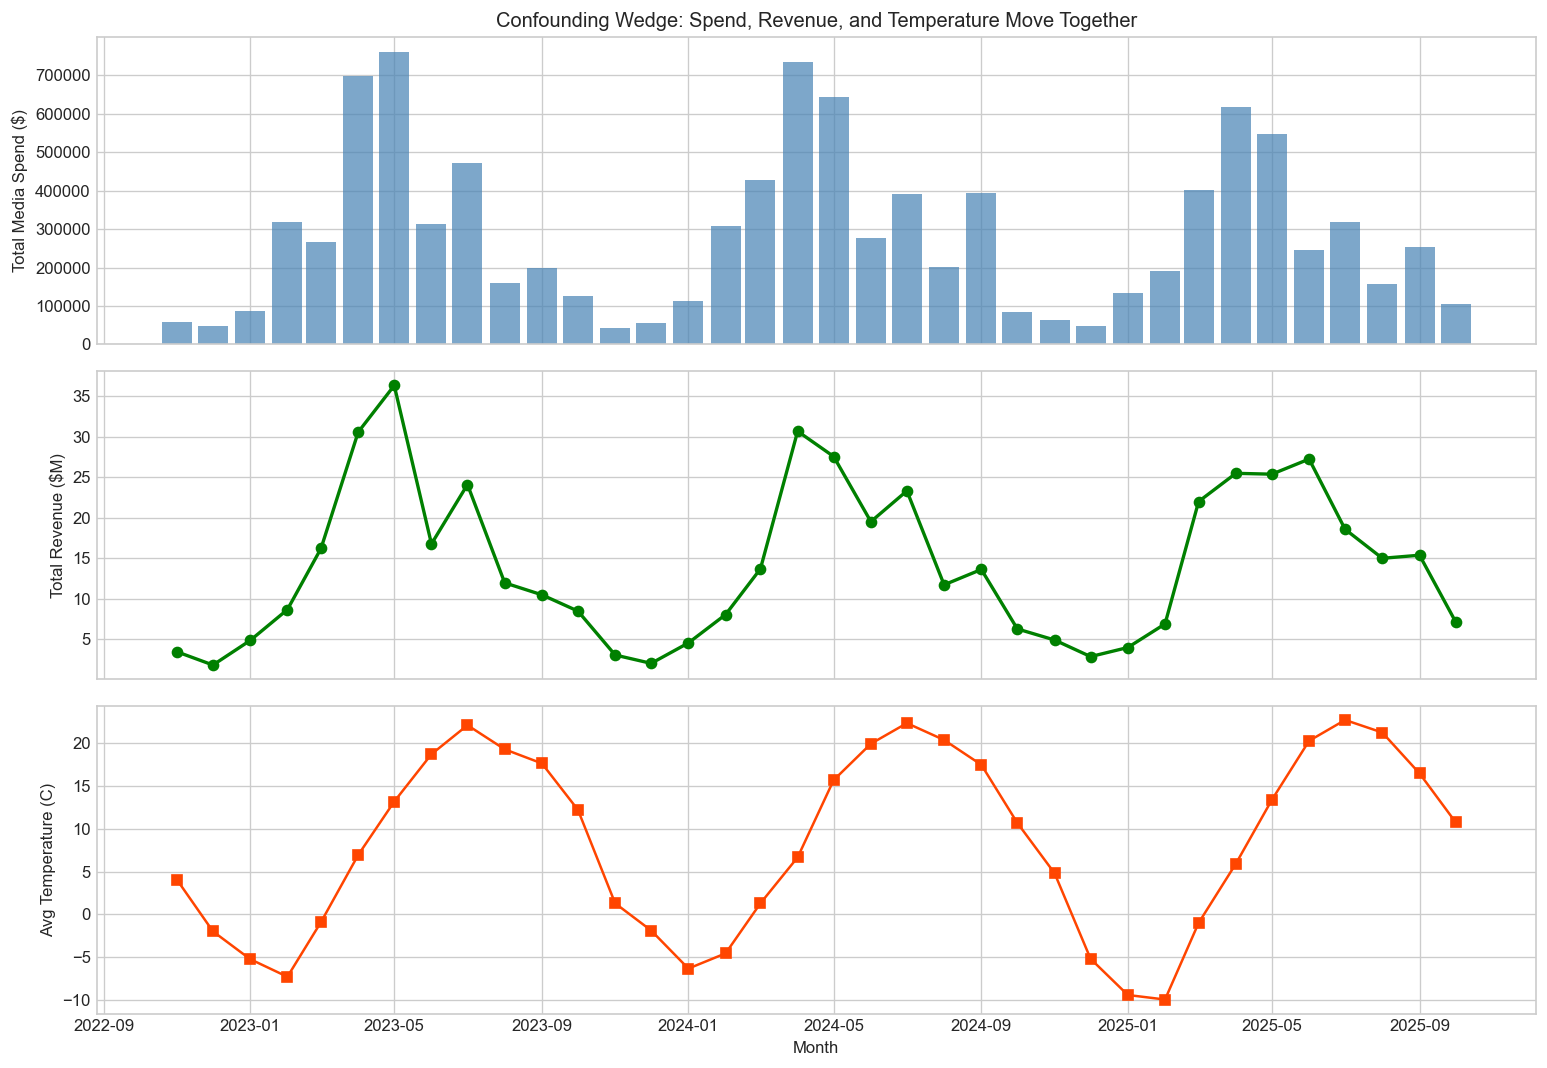

In [9]:
# ---------- Confounding wedge: spend, revenue, temperature ----------
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

ax0 = axes[0]
ax0.bar(df['date'], df['media_total'], width=25, color='steelblue', alpha=0.7)
ax0.set_ylabel('Total Media Spend ($)')
ax0.set_title('Confounding Wedge: Spend, Revenue, and Temperature Move Together')

ax1 = axes[1]
ax1.plot(df['date'], df['total_all_revenue'] / 1e6, color='green', marker='o', linewidth=2)
ax1.set_ylabel('Total Revenue ($M)')

ax2 = axes[2]
ax2.plot(df['date'], df['avg_temp_mean'], color='orangered', marker='s')
ax2.set_ylabel('Avg Temperature (C)')
ax2.set_xlabel('Month')

plt.tight_layout()
plt.savefig(figures_path / 'causal_confounding_wedge.png', dpi=150)
plt.show()

**Take-away:** All three series rise and fall together.  
Naive correlation of spend with revenue would overstate the true media effect because warm weather independently drives both ad budgets and consumer demand.  
Ridge regression with weather and Fourier seasonality controls is our main strategy to disentangle media impact from the seasonal confound.

---
## Section 3 — Model 1: OLS Baseline (per product)

In [10]:
# ---------- OLS — total revenue only (baseline) ----------
X_ols = sm.add_constant(df[FEATURE_COLS].fillna(0))

target = 'total_all_revenue'
y = df[target].values
model_ols = sm.OLS(y, X_ols).fit()

print('=' * 72)
print(f'OLS — {PRODUCT_LABELS[target]}')
print('=' * 72)
print(model_ols.summary2())
print()
print(f'Note: With {len(FEATURE_COLS)} features and {len(df)} observations, ')
print(f'OLS has {len(df) - len(FEATURE_COLS) - 1} residual df — overfitting risk is moderate.')
print(f'Ridge regression mitigates this via shrinkage.')

OLS — Total Revenue
                                     Results: Ordinary least squares
Model:                            OLS                          Adj. R-squared:                 0.945     
Dependent Variable:               y                            AIC:                            1166.1910 
Date:                             2026-02-11 17:43             BIC:                            1189.9438 
No. Observations:                 36                           Log-Likelihood:                 -568.10   
Df Model:                         14                           F-statistic:                    44.10     
Df Residuals:                     21                           Prob (F-statistic):             2.24e-12  
R-squared:                        0.967                        Scale:                          5.1088e+12
---------------------------------------------------------------------------------------------------------
                                        Coef.       Std.Err.   

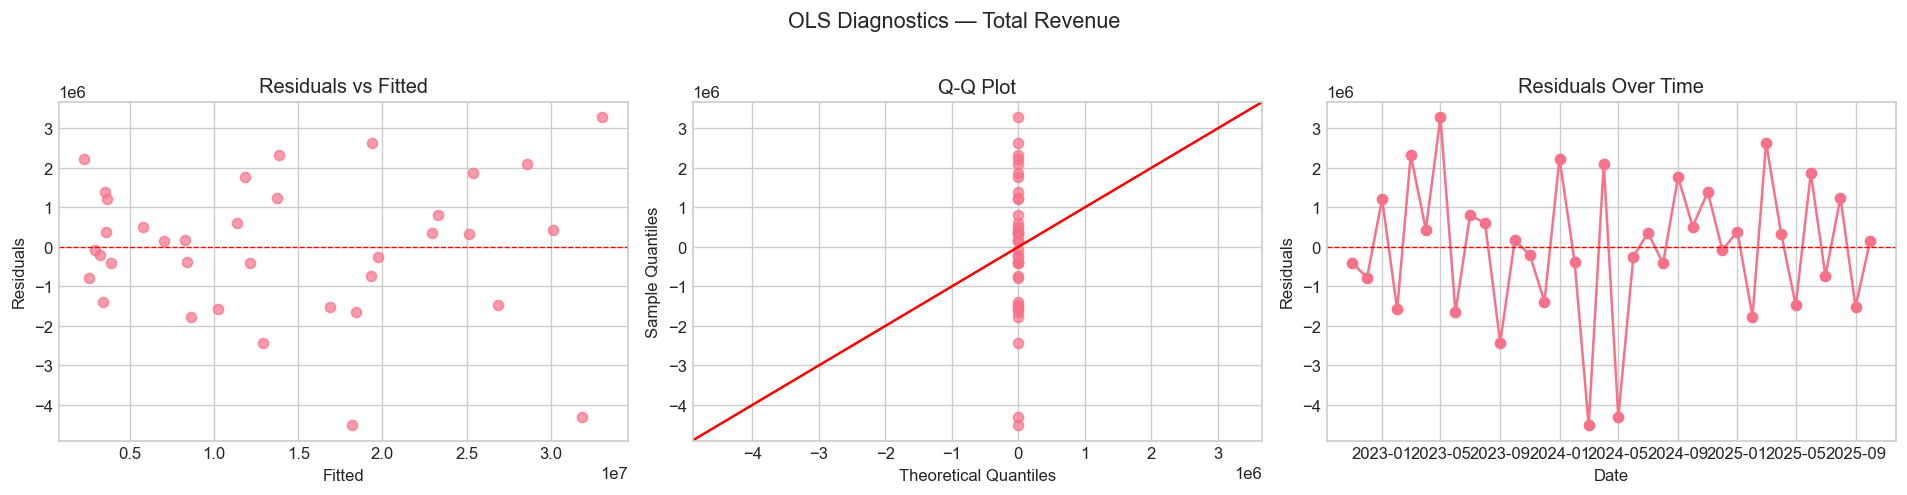

In [11]:
# ---------- OLS diagnostic plots (total revenue only) ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

resid = model_ols.resid
fitted = model_ols.fittedvalues

ax = axes[0]
ax.scatter(fitted, resid, alpha=0.7)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Fitted'); ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')

ax = axes[1]
sm.qqplot(resid, line='45', ax=ax, alpha=0.7)
ax.set_title('Q-Q Plot')

ax = axes[2]
ax.plot(df['date'], resid, marker='o')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Date'); ax.set_ylabel('Residuals')
ax.set_title('Residuals Over Time')

fig.suptitle(f'OLS Diagnostics — {PRODUCT_LABELS[target]}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'causal_ols_diagnostics.png', dpi=150)
plt.show()

---
## Section 4 — Model 2: Ridge Regression (Primary Model)

Ridge shrinks coefficients toward zero, stabilising estimates when
predictors are correlated and N is small.  
We select alpha via **leave-one-out cross-validation** (LOOCV).

**7 separate models:** total revenue + 6 product categories.

In [12]:
# ---------- Ridge with LOOCV alpha selection (all 7 targets) ----------
np.random.seed(42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURE_COLS].fillna(0))

ALPHAS = np.logspace(-2, 3, 100)

ridge_results = {}

for target in TARGET_COLS:
    y = df[target].values

    ridge_cv = RidgeCV(alphas=ALPHAS, scoring='neg_mean_squared_error',
                       cv=LeaveOneOut())
    ridge_cv.fit(X_scaled, y)
    best_alpha = ridge_cv.alpha_

    model = Ridge(alpha=best_alpha)
    model.fit(X_scaled, y)

    y_pred = model.predict(X_scaled)
    r2     = r2_score(y, y_pred)
    mae    = mean_absolute_error(y, y_pred)
    
    # Also compute LOOCV R2
    y_pred_cv = cross_val_predict(model, X_scaled, y, cv=LeaveOneOut())
    r2_cv = r2_score(y, y_pred_cv)

    ridge_results[target] = {
        'model':      model,
        'best_alpha': best_alpha,
        'r2':         r2,
        'r2_cv':      r2_cv,
        'mae':        mae,
        'y_pred':     y_pred,
    }

    print(f'{PRODUCT_LABELS[target]:30s}  alpha={best_alpha:>9.2f}   '
          f'R2={r2:.3f}   LOOCV R2={r2_cv:.3f}   MAE=${mae:,.0f}')

Total Revenue                   alpha=     0.41   R2=0.966   LOOCV R2=0.912   MAE=$1,368,274
Above-Ground Pools (HT)         alpha=     6.73   R2=0.854   LOOCV R2=0.733   MAE=$630,940
In-Ground Pools (CR)            alpha=    38.54   R2=0.668   LOOCV R2=0.531   MAE=$301,864
Spas (SP)                       alpha=     4.23   R2=0.929   LOOCV R2=0.855   MAE=$419,981
Furniture & Gazebo (ME&GA)      alpha=     2.10   R2=0.966   LOOCV R2=0.915   MAE=$692,486
Fitness (FI)                    alpha=    38.54   R2=0.570   LOOCV R2=0.415   MAE=$53,196
BBQ (BQ)                        alpha=     0.93   R2=0.958   LOOCV R2=0.887   MAE=$55,309


In [13]:
# ---------- Bootstrap for coefficient confidence intervals ----------
N_BOOT = 1000
boot_coefs = {t: [] for t in TARGET_COLS}

n = len(df)
rng = np.random.RandomState(42)

for b in range(N_BOOT):
    idx = rng.choice(n, size=n, replace=True)
    X_b = X_scaled[idx]
    for target in TARGET_COLS:
        y_b = df[target].values[idx]
        alpha_b = ridge_results[target]['best_alpha']
        m = Ridge(alpha=alpha_b).fit(X_b, y_b)
        boot_coefs[target].append(m.coef_)

# Summarise bootstrap
boot_summary = {}
for target in TARGET_COLS:
    arr = np.array(boot_coefs[target])
    boot_summary[target] = pd.DataFrame({
        'feature':  FEATURE_COLS,
        'coef':     ridge_results[target]['model'].coef_,
        'boot_mean': arr.mean(axis=0),
        'ci_lower': np.percentile(arr, 5,  axis=0),
        'ci_upper': np.percentile(arr, 95, axis=0),
    })

print('Bootstrap done (1,000 resamples).  90% CI computed.')

Bootstrap done (1,000 resamples).  90% CI computed.


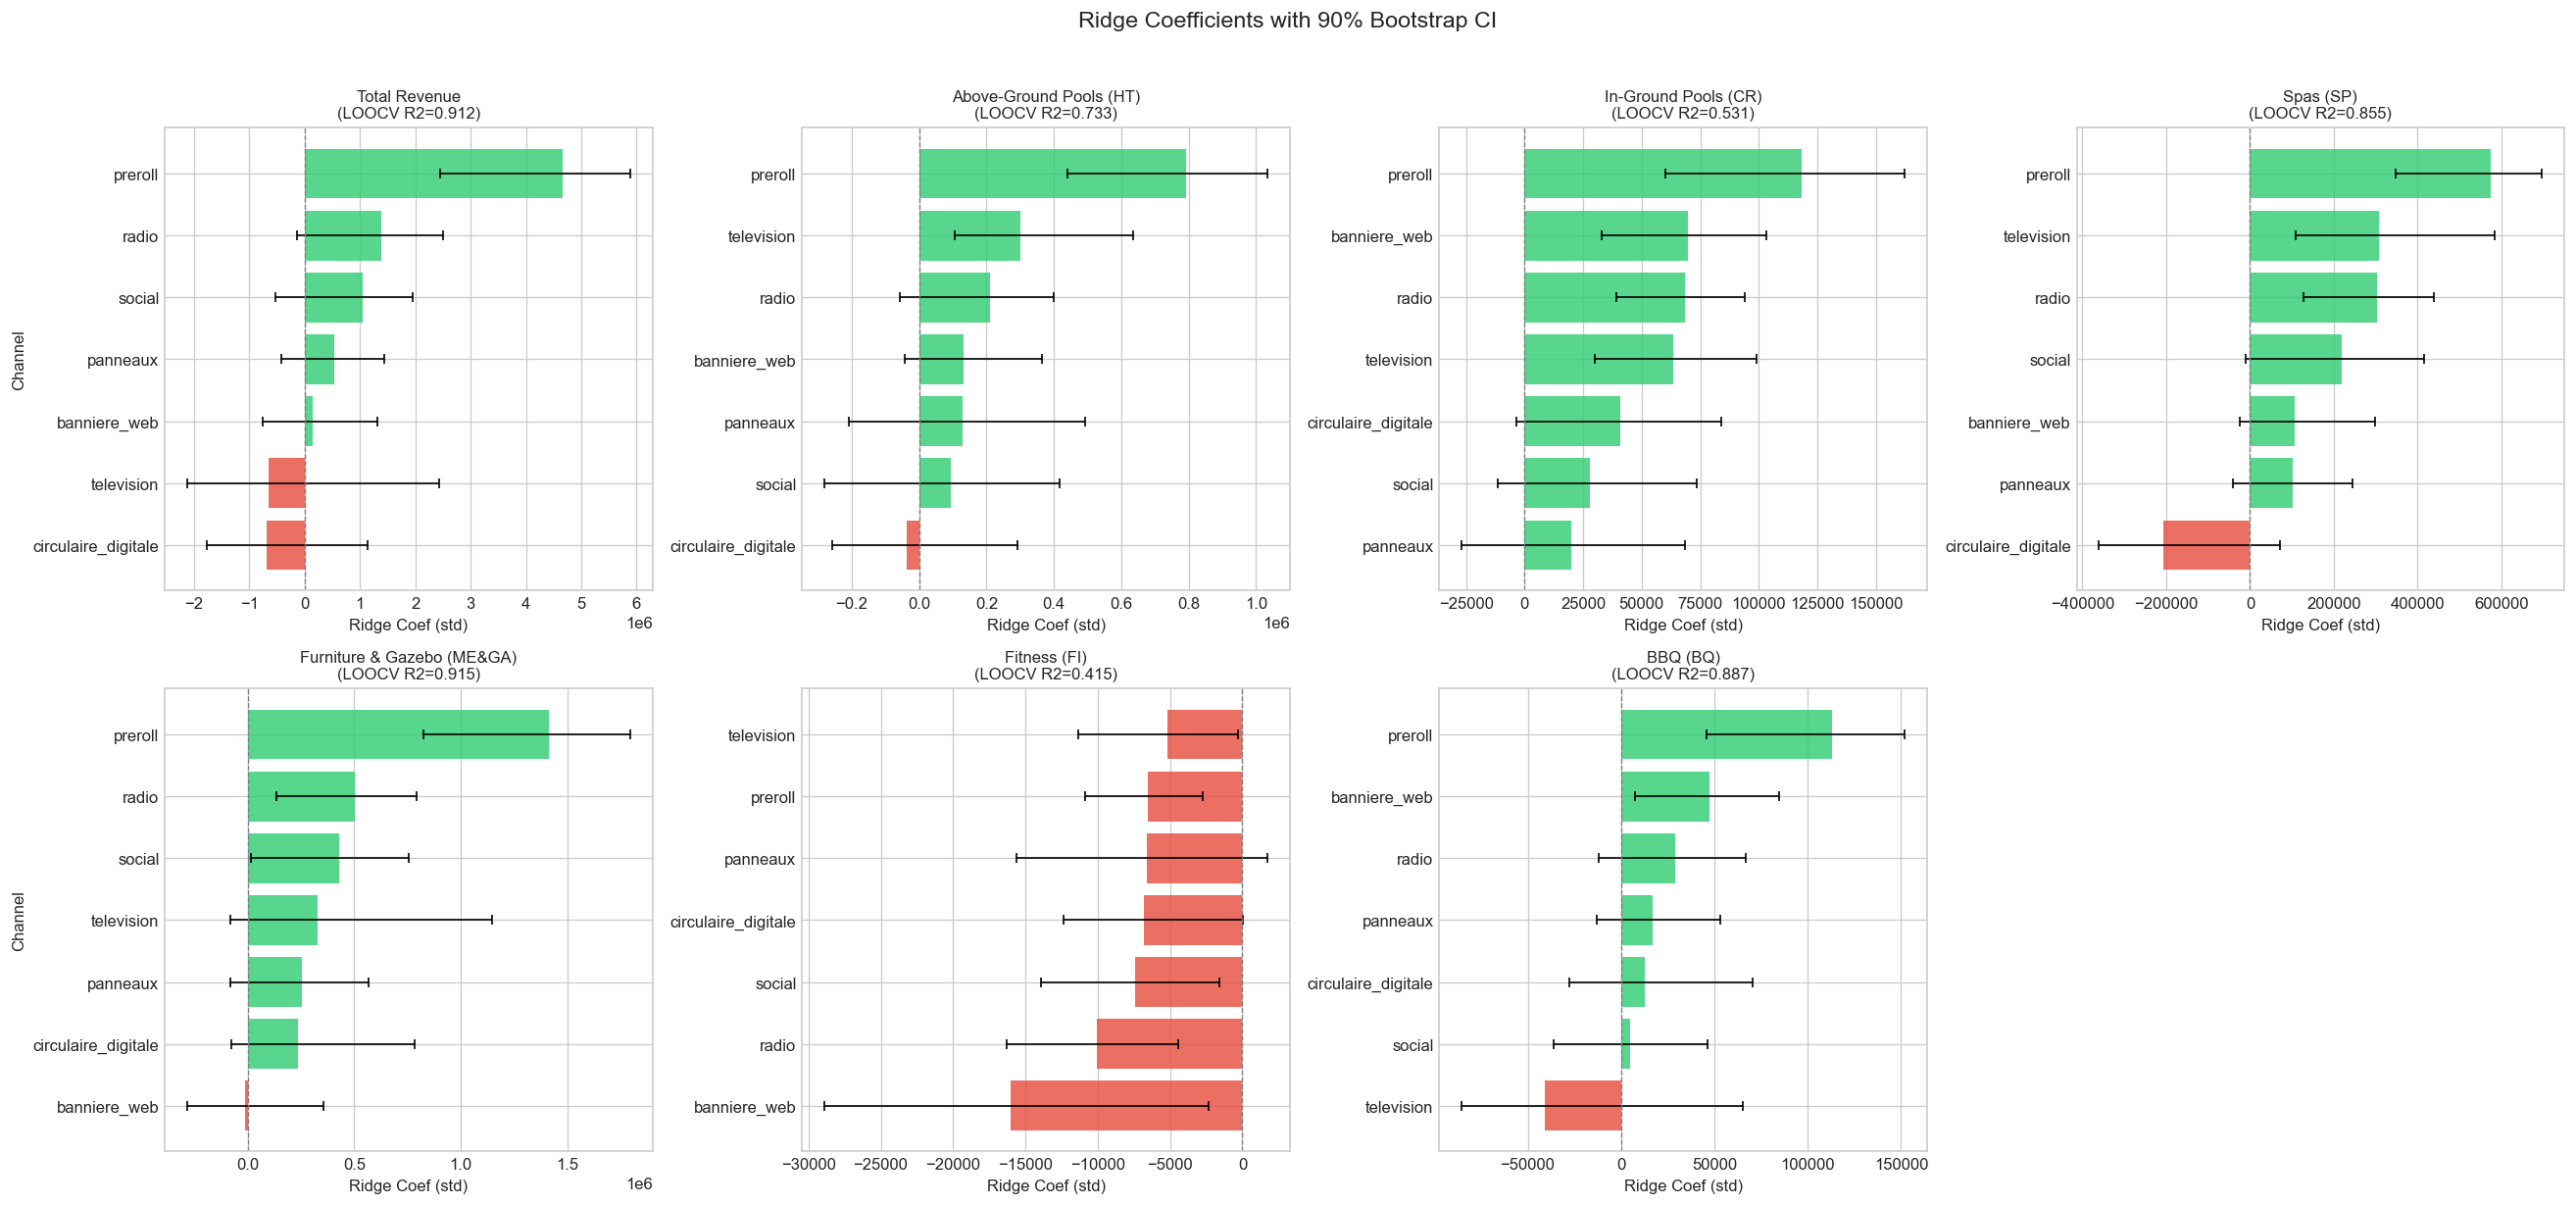

In [14]:
# ---------- Coefficient bar charts with CI (2x4 grid for 7 targets) ----------
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    bs = boot_summary[target]
    media_mask = bs['feature'].str.contains('_saturated')
    bs_media = bs[media_mask].copy()
    bs_media['label'] = bs_media['feature'].str.replace('media_', '').str.replace('_saturated', '')
    bs_media = bs_media.sort_values('coef')

    colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in bs_media['coef']]
    ax.barh(bs_media['label'], bs_media['coef'], color=colors, alpha=0.8)
    ax.errorbar(bs_media['coef'], bs_media['label'],
                xerr=[bs_media['coef'] - bs_media['ci_lower'],
                      bs_media['ci_upper'] - bs_media['coef']],
                fmt='none', ecolor='black', capsize=3, linewidth=1)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    r2 = ridge_results[target]['r2_cv']
    ax.set_title(f'{PRODUCT_LABELS[target]}\n(LOOCV R2={r2:.3f})', fontsize=10)
    ax.set_xlabel('Ridge Coef (std)')
    if idx % 4 == 0:
        ax.set_ylabel('Channel')

fig.delaxes(axes[-1])
fig.suptitle('Ridge Coefficients with 90% Bootstrap CI', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'causal_ridge_coefficients.png', dpi=150)
plt.show()

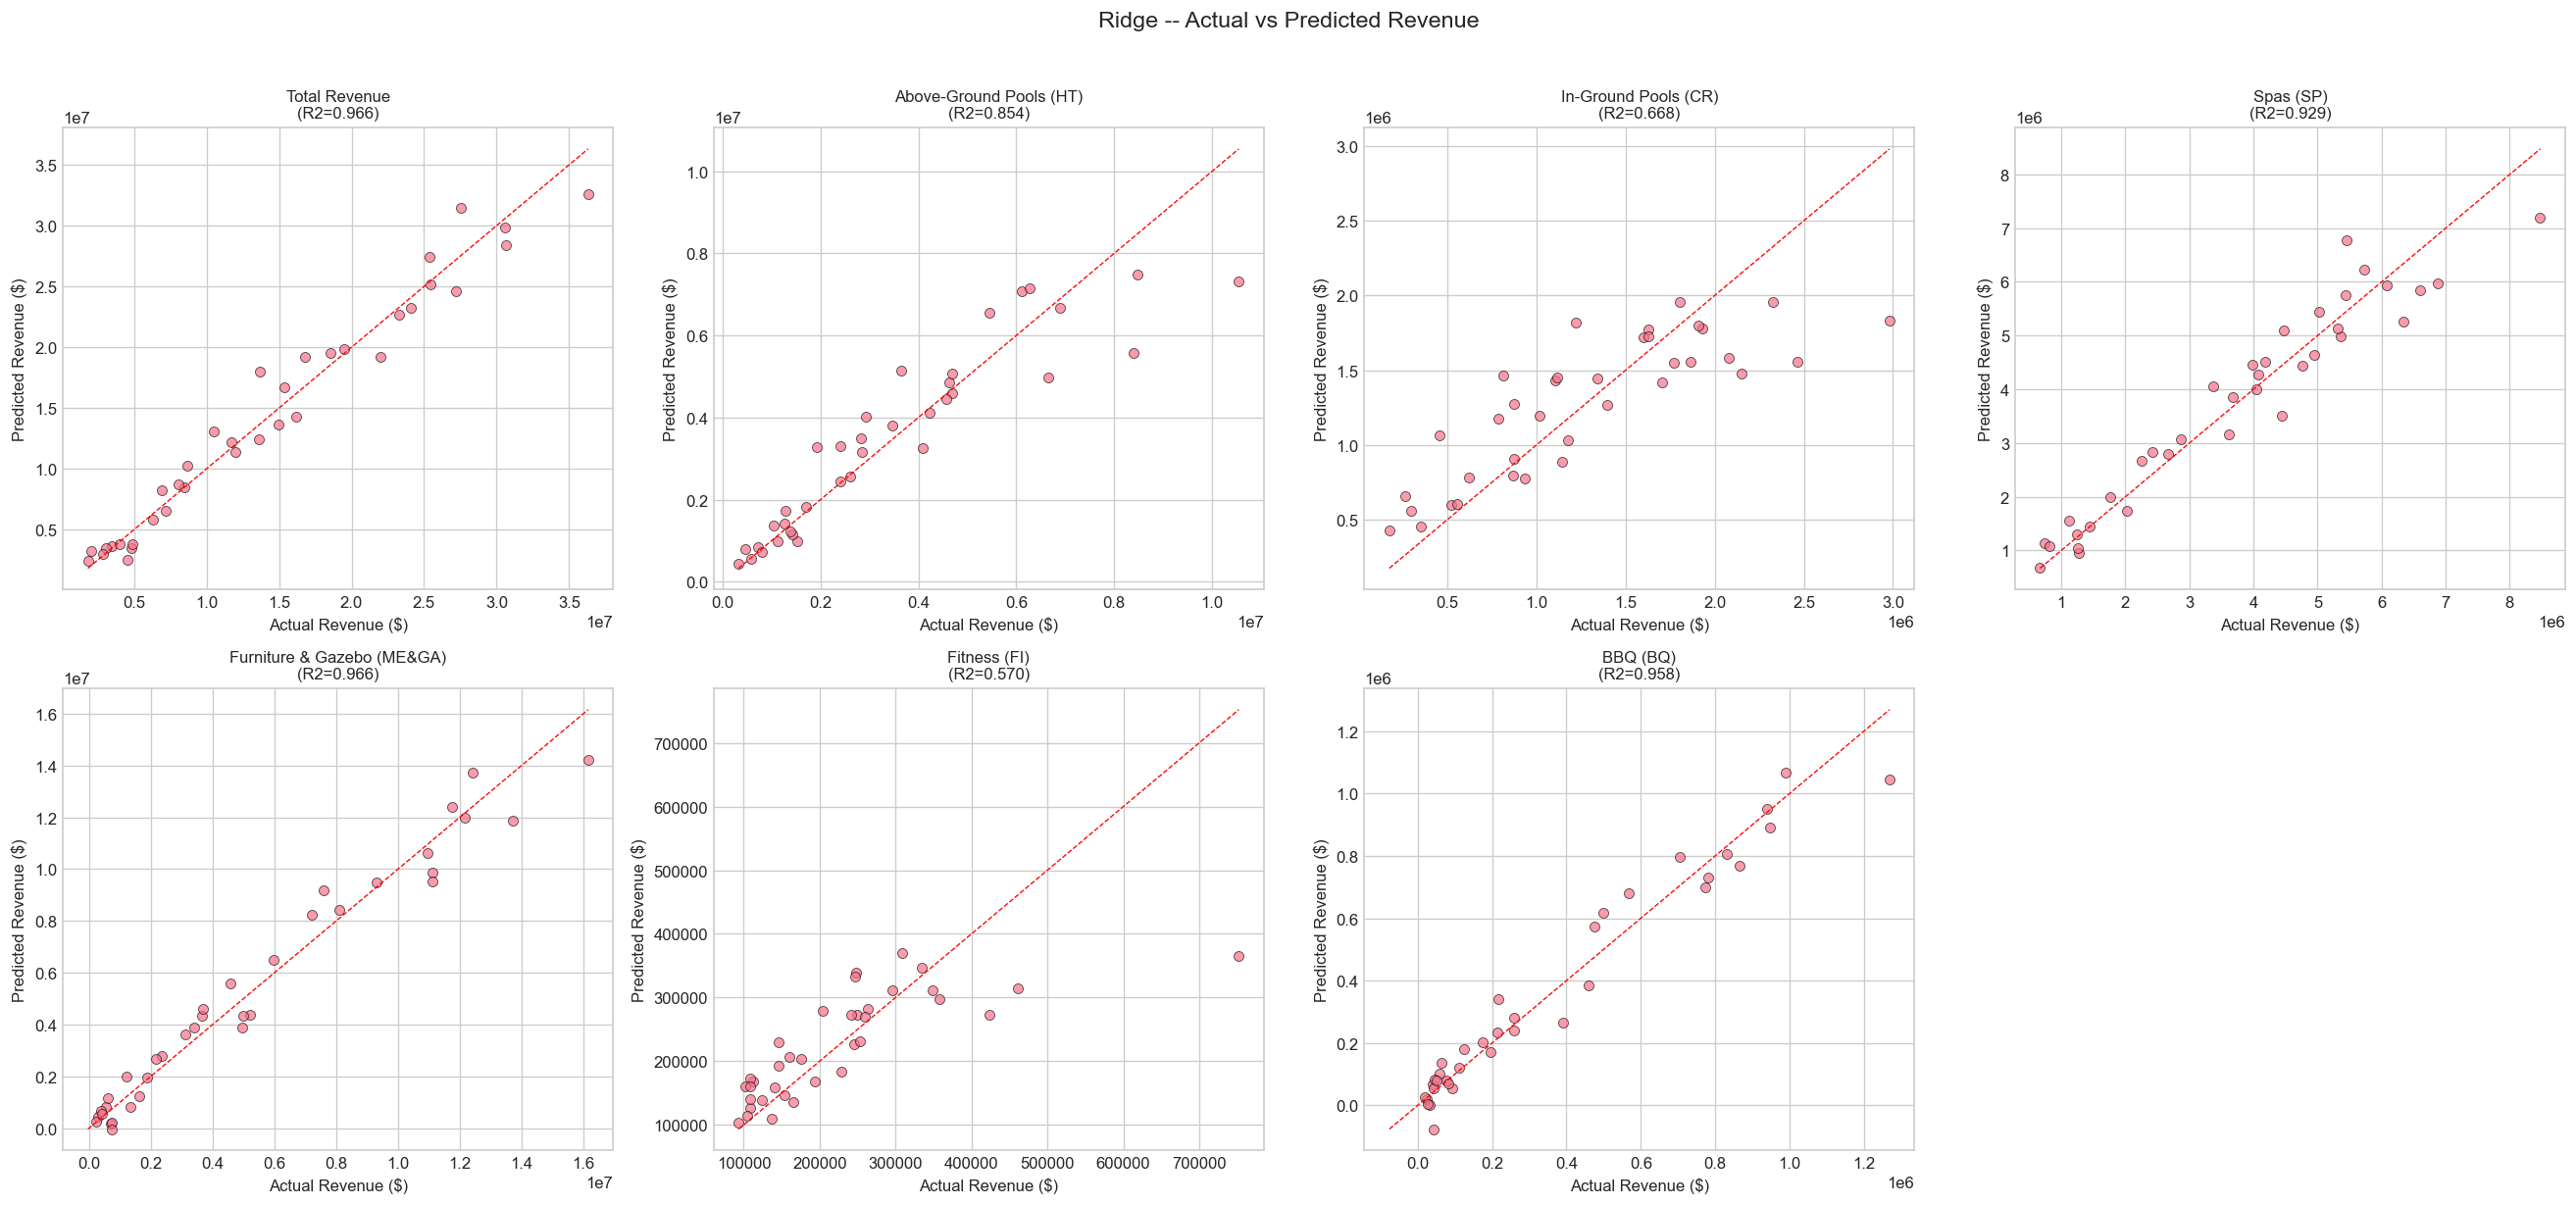

In [15]:
# ---------- Actual vs predicted (2x4 grid) ----------
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    y_true = df[target].values
    y_pred = ridge_results[target]['y_pred']
    ax.scatter(y_true, y_pred, alpha=0.7, edgecolors='k', linewidths=0.5)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=0.8)
    ax.set_xlabel('Actual Revenue ($)')
    ax.set_ylabel('Predicted Revenue ($)')
    r2 = ridge_results[target]['r2']
    ax.set_title(f'{PRODUCT_LABELS[target]}\n(R2={r2:.3f})', fontsize=10)

fig.delaxes(axes[-1])
fig.suptitle('Ridge -- Actual vs Predicted Revenue', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'causal_ridge_actual_vs_pred.png', dpi=150)
plt.show()

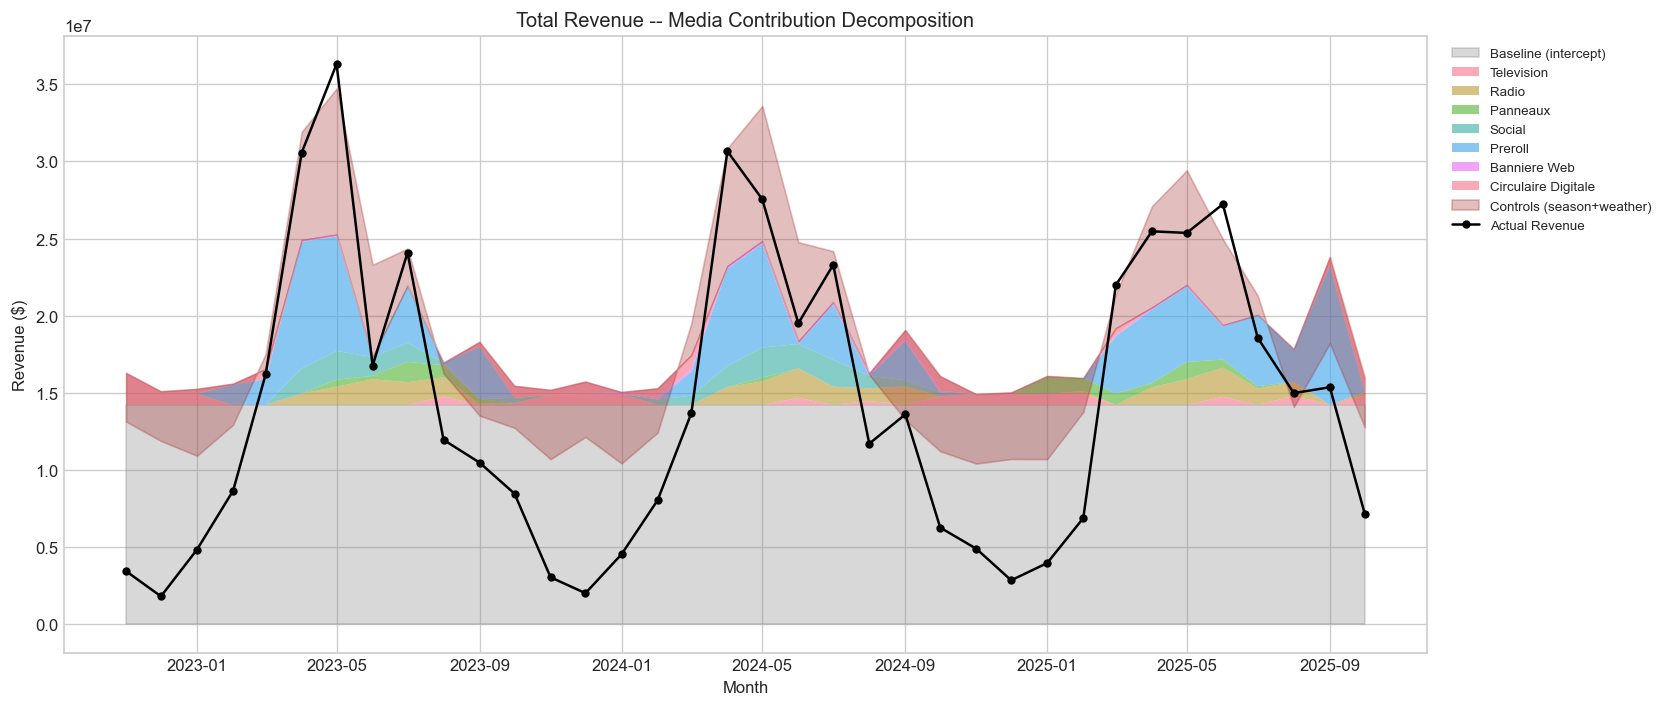

In [16]:
# ---------- Media contribution decomposition (total revenue only) ----------
target = 'total_all_revenue'
fig, ax = plt.subplots(figsize=(14, 6))

model = ridge_results[target]['model']
intercept = model.intercept_
contribs = X_scaled * model.coef_
media_idx = [FEATURE_COLS.index(c) for c in SATURATED_COLS]
ctrl_idx  = [FEATURE_COLS.index(c) for c in CONTROL_COLS]

media_contribs = pd.DataFrame(
    contribs[:, media_idx],
    columns=[c.replace('media_', '').replace('_saturated', '') for c in SATURATED_COLS]
)
media_pos = media_contribs.clip(lower=0)
control_contrib = contribs[:, ctrl_idx].sum(axis=1)

ax.fill_between(df['date'], 0, intercept, alpha=0.3, label='Baseline (intercept)', color='grey')
bottom = np.full(len(df), intercept)
for col in media_pos.columns:
    vals = media_pos[col].values
    ax.fill_between(df['date'], bottom, bottom + vals, alpha=0.6, label=col.replace('_', ' ').title())
    bottom = bottom + vals
ax.fill_between(df['date'], bottom, bottom + control_contrib, alpha=0.3,
                label='Controls (season+weather)', color='brown')
ax.plot(df['date'], df[target], 'ko-', markersize=4, label='Actual Revenue', linewidth=1.5)
ax.set_ylabel('Revenue ($)')
ax.set_title(f'{PRODUCT_LABELS[target]} -- Media Contribution Decomposition')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xlabel('Month')

plt.tight_layout()
plt.savefig(figures_path / 'causal_media_decomposition.png', dpi=150)
plt.show()

In [17]:
# ---------- Cross-product comparison table ----------
print('Ridge Coefficients -- Media Channels (standardised scale)')
print('=' * 120)
rows = []
for ch in SATURATED_COLS:
    label = ch.replace('media_', '').replace('_saturated', '')
    row = {'Channel': label}
    for target in TARGET_COLS:
        bs = boot_summary[target]
        r = bs[bs['feature'] == ch].iloc[0]
        row[PRODUCT_LABELS[target]] = f"{r['coef']:>8.1f}  [{r['ci_lower']:>7.1f}, {r['ci_upper']:>7.1f}]"
    rows.append(row)

coef_table = pd.DataFrame(rows).set_index('Channel')
print(coef_table.to_string())

Ridge Coefficients -- Media Channels (standardised scale)
                                          Total Revenue          Above-Ground Pools (HT)           In-Ground Pools (CR)                        Spas (SP)        Furniture & Gazebo (ME&GA)                   Fitness (FI)                       BBQ (BQ)
Channel                                                                                                                                                                                                                                                 
television           -644914.7  [-2126485.2, 2422560.9]   301366.0  [105741.0, 635176.6]    63640.2  [29880.1, 99184.4]   307711.0  [109580.0, 584631.5]   328362.3  [-81136.7, 1148464.9]   -5214.1  [-11346.7,  -291.4]  -40754.2  [-85433.5, 65467.1]
radio                 1379243.3  [-143861.8, 2495815.1]   211345.8  [-56132.7, 398298.3]    68312.4  [39160.2, 93985.3]   302837.0  [128858.9, 438868.0]    501935.7  [135270.7, 795036.8]  -10040.

---
## Section 5 — Model 3: Elastic Net (Variable Selection Check)

Elastic Net combines L1 (lasso, variable selection) and L2 (ridge) penalties.  
We use it to check **which channels get zeroed out** — i.e., which ones Lasso deems uninformative.

In [18]:
# ---------- Elastic Net (total revenue + 6 categories) ----------
enet_results = {}

for target in TARGET_COLS:
    y = df[target].values
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        alphas=np.logspace(-3, 2, 50),
        cv=LeaveOneOut(),
        max_iter=10_000,
    )
    enet.fit(X_scaled, y)
    enet_results[target] = enet
    print(f'{PRODUCT_LABELS[target]:30s}  alpha={enet.alpha_:.4f}  '
          f'l1_ratio={enet.l1_ratio_:.2f}  '
          f'non-zero={np.sum(enet.coef_ != 0)}/{len(enet.coef_)}  '
          f'R2={r2_score(y, enet.predict(X_scaled)):.3f}')

Total Revenue                   alpha=0.0133  l1_ratio=0.10  non-zero=14/14  R2=0.966
Above-Ground Pools (HT)         alpha=0.2812  l1_ratio=0.30  non-zero=14/14  R2=0.853
In-Ground Pools (CR)            alpha=3.7276  l1_ratio=0.70  non-zero=14/14  R2=0.666
Spas (SP)                       alpha=1.1514  l1_ratio=0.90  non-zero=14/14  R2=0.929
Furniture & Gazebo (ME&GA)      alpha=0.0687  l1_ratio=0.10  non-zero=14/14  R2=0.965
Fitness (FI)                    alpha=1.1514  l1_ratio=0.10  non-zero=14/14  R2=0.572
BBQ (BQ)                        alpha=0.0869  l1_ratio=0.70  non-zero=14/14  R2=0.958


In [19]:
# ---------- Coefficient comparison: OLS vs Ridge vs Elastic Net (total revenue) ----------
target = 'total_all_revenue'
print(f'\n{"=" * 72}')
print(f'{PRODUCT_LABELS[target]} -- Coefficient Comparison')
print(f'{"=" * 72}')

ols_coefs = model_ols.params[1:]  # skip constant
ridge_coefs = ridge_results[target]['model'].coef_
enet_coefs  = enet_results[target].coef_

comp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'OLS':     ols_coefs.values,
    'Ridge':   ridge_coefs,
    'ElasticNet': enet_coefs,
})
comp['label'] = comp['Feature'].str.replace('media_', '').str.replace('_saturated', '').str.replace('_scaled', '')
comp = comp[['label', 'OLS', 'Ridge', 'ElasticNet']]
print(comp.to_string(index=False, float_format='{:>10.1f}'.format))


Total Revenue -- Coefficient Comparison
               label        OLS      Ridge  ElasticNet
          television -2463872.5  -644914.7   -626236.9
               radio    11087.4  1379243.3   1373865.2
            panneaux     6763.8   530851.8    530192.6
              social    34145.2  1055010.1   1052345.9
             preroll 25932292.3  4666676.7   4649206.9
        banniere_web   829967.8   138269.7    139274.3
 circulaire_digitale   -15288.3  -693658.3   -686730.4
               sin_1  5635297.1  3236489.2   3218267.1
               cos_1   355943.0 -1143877.1  -1170485.6
               sin_2 -2641329.5 -1716091.8  -1712294.3
               cos_2  1376750.1   854076.2    851814.6
total_sunshine_hours  3988465.5  2643015.0   2616601.1
 total_precipitation  1973254.0  1477417.2   1466642.2
       days_above_25  -421729.9  -311916.1   -309057.8


---
## Section 6 — Channel Effectiveness Metrics (Key Deliverable)

Translate Ridge coefficients back into **business metrics**:

- Marginal effect: additional revenue per $1,000 extra spend.
- ROAS: return on ad spend for each channel.
- Saturation level: how saturated is each channel at current spend?
- Cross-product heatmap.

In [20]:
# ===================================================================
# 6-A  MARGINAL EFFECTS  (dRevenue / d$1000)
# ===================================================================

effectiveness_rows = []

for target in TARGET_COLS:
    model = ridge_results[target]['model']
    bs    = boot_summary[target]

    for i, ch in enumerate(MEDIA_CHANNELS):
        sat_col = SATURATED_COLS[i]
        feat_idx = FEATURE_COLS.index(sat_col)
        beta_std = model.coef_[feat_idx]

        sat_std = df[sat_col].std()

        # Use median of non-zero adstock (avoids zero-inflated mean bias)
        adstock_nz = df[f'{ch}_adstock'][df[f'{ch}_adstock'] > 0]
        adstock_eval = float(adstock_nz.median()) if len(adstock_nz) > 0 else 0

        # Compute derivative based on saturation type
        sat_type = SATURATION_PARAMS[ch]['type']
        if sat_type == 'hill':
            K = SATURATION_PARAMS[ch]['K']
            alpha_h = SATURATION_PARAMS[ch]['alpha']
            dS_dx = float(hill_derivative(adstock_eval, K, alpha_h))
        elif sat_type == 'log':
            scale = SATURATION_PARAMS[ch]['scale']
            dS_dx = 1.0 / (scale + adstock_eval) if (scale + adstock_eval) > 0 else 0
        elif sat_type == 'power':
            beta_p = SATURATION_PARAMS[ch]['beta']
            dS_dx = beta_p * adstock_eval**(beta_p - 1) if adstock_eval > 0 else 0
        else:
            dS_dx = 0

        lam = DECAY_RATES[ch]
        adstock_gain = 1.0 / (1.0 - lam)

        if sat_std > 0:
            marginal_per_dollar = beta_std / sat_std * dS_dx * adstock_gain
        else:
            marginal_per_dollar = 0.0

        marginal_per_1000 = marginal_per_dollar * 1000
        roas = marginal_per_dollar

        total_spend = df[ch].sum()
        contrib = float((X_scaled[:, feat_idx] * beta_std).sum())
        current_sat = float(df[sat_col].mean()) * 100

        # Bootstrap CI
        boot_arr = np.array(boot_coefs[target])[:, feat_idx]
        if sat_std > 0:
            boot_marginals = boot_arr / sat_std * dS_dx * adstock_gain * 1000
        else:
            boot_marginals = np.zeros(N_BOOT)
        ci_lo = float(np.percentile(boot_marginals, 5))
        ci_hi = float(np.percentile(boot_marginals, 95))

        effectiveness_rows.append({
            'product':     PRODUCT_LABELS[target],
            'channel':     ch.replace('media_', ''),
            'total_spend': total_spend,
            'ridge_coef_std': beta_std,
            'marginal_per_1000': marginal_per_1000,
            'marginal_ci_lo': ci_lo,
            'marginal_ci_hi': ci_hi,
            'roas': roas,
            'total_contribution': contrib,
            'saturation_pct': current_sat,
        })

eff_df = pd.DataFrame(effectiveness_rows)

# Display for total revenue
target = 'total_all_revenue'
label = PRODUCT_LABELS[target]
print(f'\n{"=" * 100}')
print(f'  {label} -- Channel Effectiveness')
print(f'{"=" * 100}')
sub = eff_df[eff_df['product'] == label].copy()
sub = sub.sort_values('marginal_per_1000', ascending=False)
display_cols = ['channel', 'total_spend', 'marginal_per_1000',
                'marginal_ci_lo', 'marginal_ci_hi', 'roas', 'saturation_pct']
print(sub[display_cols].to_string(index=False, float_format='{:.2f}'.format))


  Total Revenue -- Channel Effectiveness
            channel  total_spend  marginal_per_1000  marginal_ci_lo  marginal_ci_hi   roas  saturation_pct
            preroll    812647.80          321457.72       168099.77       405599.15 321.46           21.89
       social_media    827420.60          145396.56       -73200.21       269956.45 145.40        19181.06
           panneaux    292495.02           73513.39       -59693.20       198122.60  73.51         7942.29
              radio   2167276.63           27473.46        -2865.62        49714.71  27.47        30798.83
       banniere_web   1762168.16            8436.55       -45966.48        79697.40   8.44           73.86
         television   3948951.24           -5608.07       -18491.57        21066.19  -5.61           54.42
circulaire_digitale    446545.72          -69861.07      -178542.30       114838.79 -69.86        11855.72


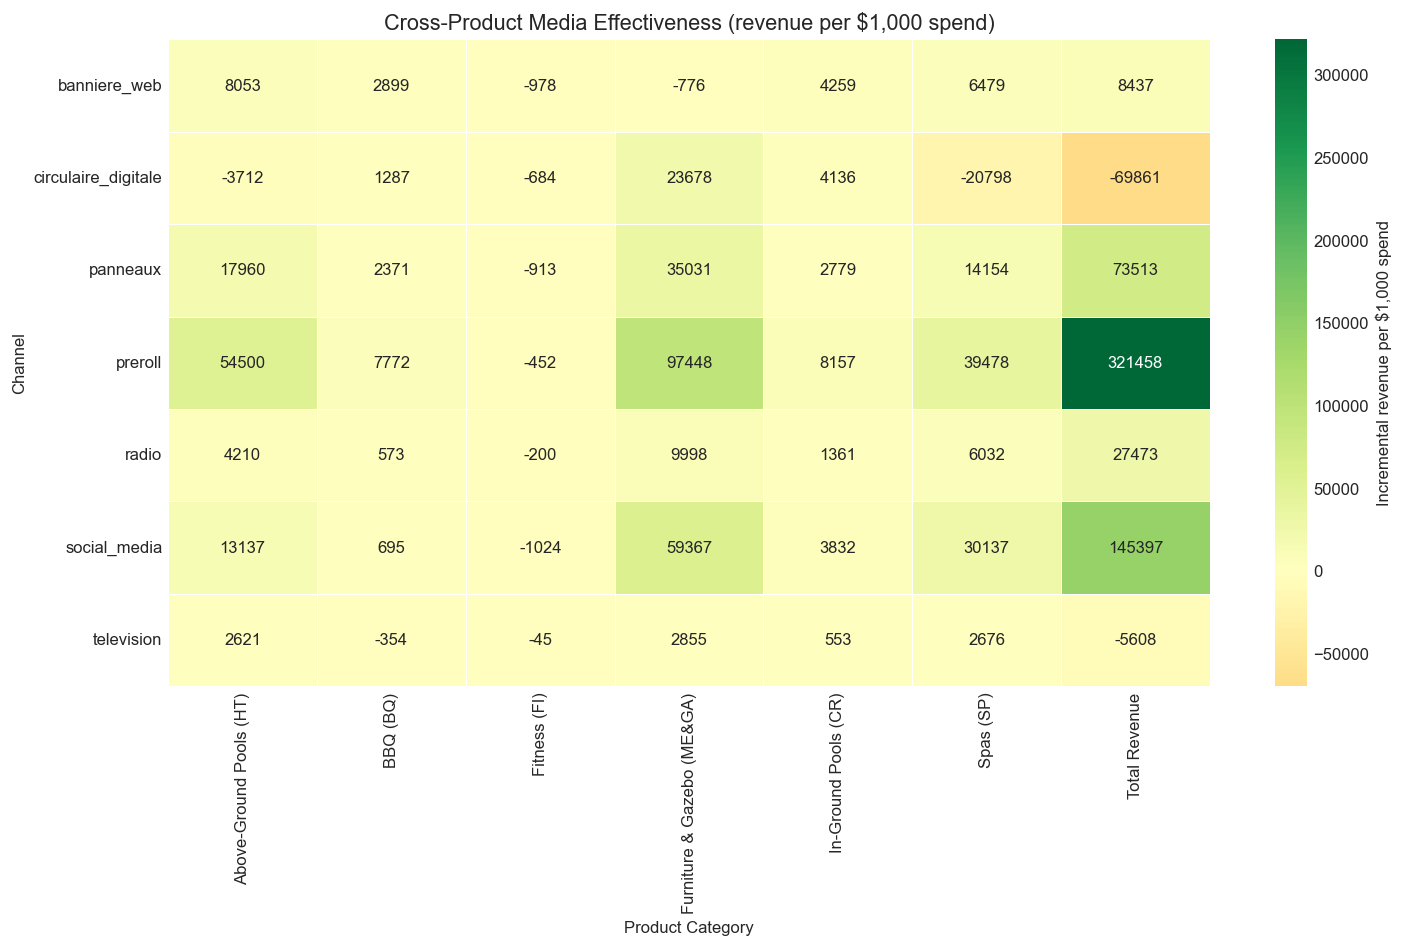

In [21]:
# ---------- Cross-product effectiveness heatmap ----------
pivot = eff_df.pivot_table(index='channel', columns='product',
                           values='marginal_per_1000')

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Incremental revenue per $1,000 spend'})
ax.set_title('Cross-Product Media Effectiveness (revenue per $1,000 spend)', fontsize=13)
ax.set_ylabel('Channel')
ax.set_xlabel('Product Category')
plt.savefig(figures_path / 'causal_effectiveness_heatmap.png', dpi=150)
plt.show()

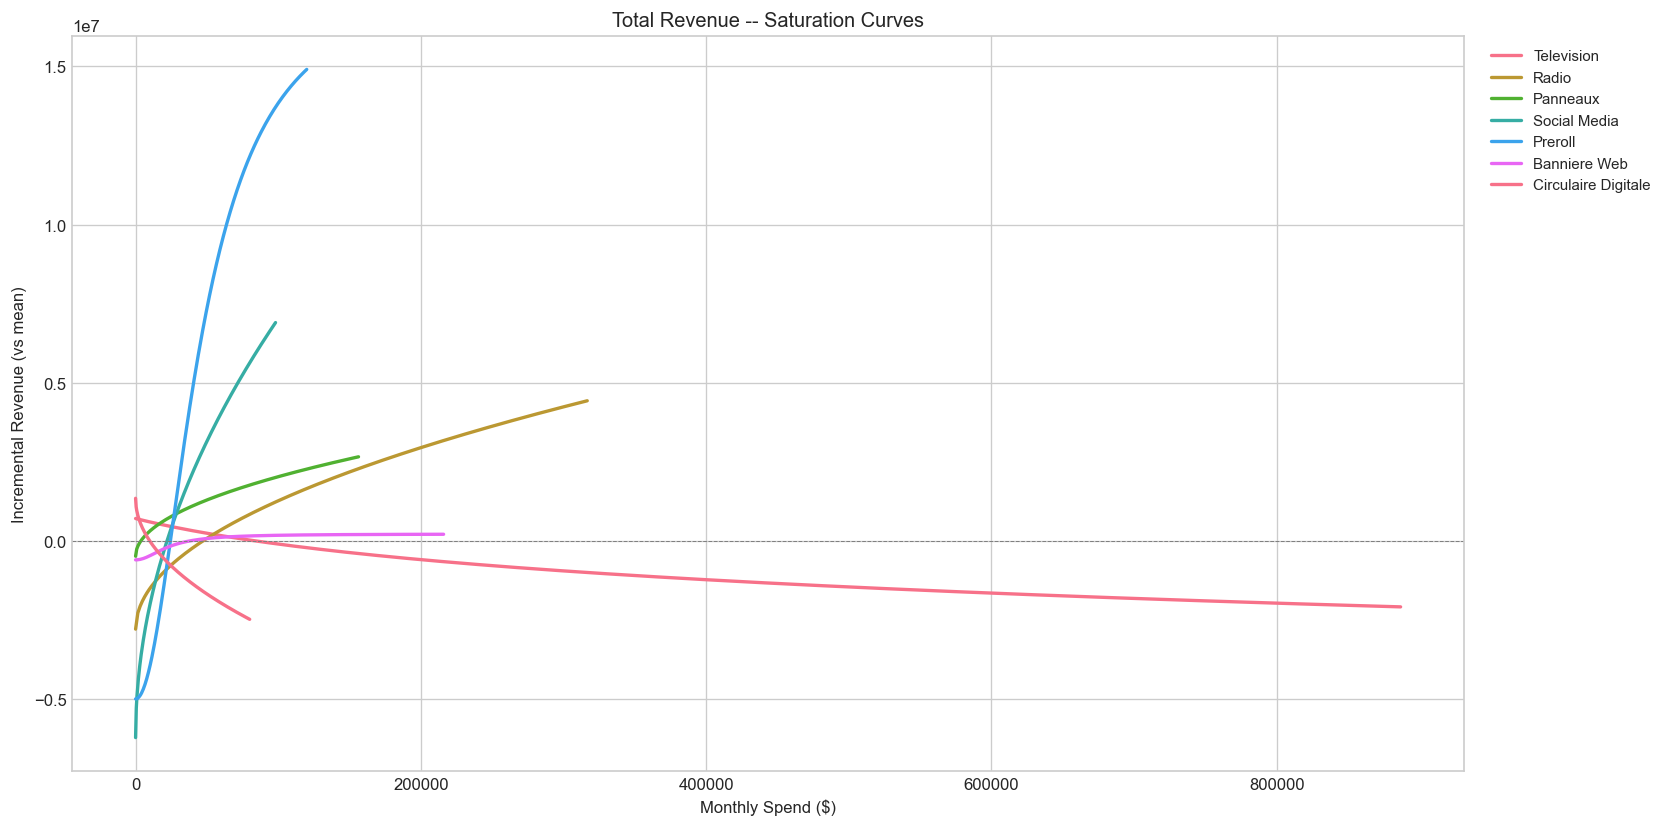

In [22]:
# ---------- Saturation curves (total revenue only) ----------
target = 'total_all_revenue'
fig, ax = plt.subplots(figsize=(14, 7))

model = ridge_results[target]['model']
saturation_curve_rows = []

for i, ch in enumerate(MEDIA_CHANNELS):
    sat_col  = SATURATED_COLS[i]
    feat_idx = FEATURE_COLS.index(sat_col)
    beta_std = model.coef_[feat_idx]
    sat_std  = df[sat_col].std()
    sat_mean_val = df[sat_col].mean()

    sat_type = SATURATION_PARAMS[ch]['type']
    lam = DECAY_RATES[ch]

    max_spend = max(df[ch].max() * 2, 1000)
    spend_grid = np.linspace(0, max_spend, 200)
    adstock_grid = spend_grid / (1 - lam)

    # Apply the correct saturation function
    if sat_type == 'hill':
        sat_grid = hill_saturation(adstock_grid, SATURATION_PARAMS[ch]['K'],
                                    SATURATION_PARAMS[ch]['alpha'])
    elif sat_type == 'log':
        sat_grid = log_saturation(adstock_grid, SATURATION_PARAMS[ch]['scale'])
    elif sat_type == 'power':
        sat_grid = power_saturation(adstock_grid, SATURATION_PARAMS[ch]['beta'])
    else:
        sat_grid = adstock_grid

    if sat_std > 0:
        revenue_grid = beta_std / sat_std * (sat_grid - sat_mean_val)
    else:
        revenue_grid = np.zeros_like(sat_grid)

    label = ch.replace('media_', '').replace('_', ' ').title()
    ax.plot(spend_grid, revenue_grid, linewidth=2, label=label)

    for s, r in zip(spend_grid[::20], revenue_grid[::20]):
        saturation_curve_rows.append({
            'product': PRODUCT_LABELS[target],
            'channel': ch.replace('media_', ''),
            'spend': s,
            'incremental_revenue': r,
        })

ax.set_xlabel('Monthly Spend ($)')
ax.set_ylabel('Incremental Revenue (vs mean)')
ax.set_title(f'{PRODUCT_LABELS[target]} -- Saturation Curves')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.6)

plt.tight_layout()
plt.savefig(figures_path / 'causal_saturation_curves.png', dpi=150)
plt.show()

sat_curves_df = pd.DataFrame(saturation_curve_rows)

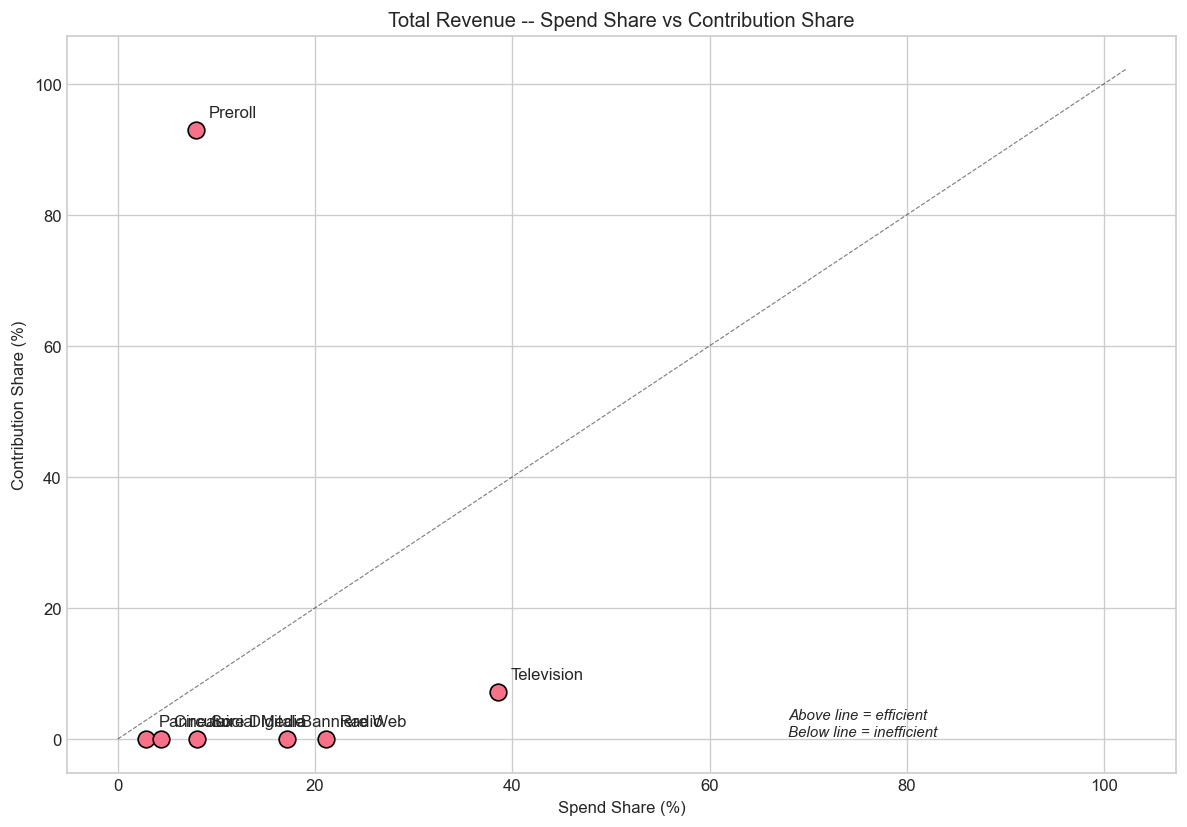

In [23]:
# ---------- Efficiency frontier (total revenue) ----------
target = 'total_all_revenue'
fig, ax = plt.subplots(figsize=(10, 7))

label = PRODUCT_LABELS[target]
sub = eff_df[eff_df['product'] == label].copy()
total_sp = sub['total_spend'].sum()
sub['abs_contrib'] = sub['total_contribution'].clip(lower=0)
total_c = sub['abs_contrib'].sum()
sub['spend_share']  = sub['total_spend'] / total_sp * 100 if total_sp > 0 else 0
sub['contrib_share'] = sub['abs_contrib'] / total_c * 100 if total_c > 0 else 0

ax.scatter(sub['spend_share'], sub['contrib_share'], s=100, zorder=3, edgecolors='k')
for _, r in sub.iterrows():
    ax.annotate(r['channel'].replace('_', ' ').title(),
                (r['spend_share'], r['contrib_share']),
                textcoords='offset points', xytext=(8, 8), fontsize=10)
mn, mx = 0, max(sub['spend_share'].max(), sub['contrib_share'].max()) * 1.1
ax.plot([0, mx], [0, mx], 'k--', linewidth=0.7, alpha=0.5)
ax.set_xlabel('Spend Share (%)')
ax.set_ylabel('Contribution Share (%)')
ax.set_title(f'{label} -- Spend Share vs Contribution Share')
ax.annotate('Above line = efficient\nBelow line = inefficient',
            xy=(0.65, 0.05), xycoords='axes fraction', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig(figures_path / 'causal_efficiency_frontier.png', dpi=150)
plt.show()

---
## Section 7 — Robustness Checks

In [24]:
# ===================================================================
# 7-A  SENSITIVITY TO ADSTOCK DECAY RATES (+/- 0.1)
# ===================================================================

decay_variants = {'low': -0.1, 'base': 0.0, 'high': +0.1}
sensitivity_decay = []

for variant_name, delta in decay_variants.items():
    df_tmp = df_raw.copy().sort_values('date').reset_index(drop=True)

    for media_col, spend_col in SPEND_TO_MEDIA.items():
        df_tmp[media_col] = df_tmp[spend_col].fillna(0)

    for ch in MEDIA_CHANNELS:
        lam = np.clip(DECAY_RATES[ch] + delta, 0.05, 0.95)
        df_tmp[f'{ch}_adstock'] = geometric_adstock(df_tmp[ch].fillna(0).values, lam)

    # Keep saturation params FIXED at baseline (only vary decay rate)
    for ch in MEDIA_CHANNELS:
        adstock_col = f'{ch}_adstock'
        sat_type = SATURATION_PARAMS[ch]['type']
        if sat_type == 'hill':
            K = SATURATION_PARAMS[ch]['K']
            alpha_h = SATURATION_PARAMS[ch]['alpha']
            df_tmp[f'{ch}_saturated'] = hill_saturation(df_tmp[adstock_col].values, K, alpha_h)
        elif sat_type == 'log':
            scale = SATURATION_PARAMS[ch]['scale']
            df_tmp[f'{ch}_saturated'] = log_saturation(df_tmp[adstock_col].values, scale)
        elif sat_type == 'power':
            beta_p = SATURATION_PARAMS[ch]['beta']
            df_tmp[f'{ch}_saturated'] = power_saturation(df_tmp[adstock_col].values, beta_p)

    df_tmp['sin_1'] = np.sin(2 * np.pi * df_tmp['month_num'] / 12)
    df_tmp['cos_1'] = np.cos(2 * np.pi * df_tmp['month_num'] / 12)
    df_tmp['sin_2'] = np.sin(4 * np.pi * df_tmp['month_num'] / 12)
    df_tmp['cos_2'] = np.cos(4 * np.pi * df_tmp['month_num'] / 12)
    for wcol in ['total_sunshine_hours', 'total_precipitation', 'days_above_25']:
        df_tmp[f'{wcol}_scaled'] = (df_tmp[wcol] - df_tmp[wcol].mean()) / df_tmp[wcol].std()

    X_tmp = StandardScaler().fit_transform(df_tmp[FEATURE_COLS].fillna(0))

    for target in TARGET_COLS:
        y = df_tmp[target].values
        alpha_r = ridge_results[target]['best_alpha']
        m = Ridge(alpha=alpha_r).fit(X_tmp, y)
        for j, ch in enumerate(MEDIA_CHANNELS):
            sensitivity_decay.append({
                'variant': variant_name,
                'product': PRODUCT_LABELS[target],
                'channel': ch.replace('media_', ''),
                'coef': m.coef_[j],
            })

sens_decay_df = pd.DataFrame(sensitivity_decay)
pivot_sens = sens_decay_df.pivot_table(index=['product', 'channel'], columns='variant', values='coef')
pivot_sens = pivot_sens[['low', 'base', 'high']]
pivot_sens['sign_stable'] = ((pivot_sens['low'] > 0) & (pivot_sens['high'] > 0)) | \
                            ((pivot_sens['low'] < 0) & (pivot_sens['high'] < 0)) | \
                            ((pivot_sens['low'] == 0) & (pivot_sens['high'] == 0))

total_label = PRODUCT_LABELS['total_all_revenue']
print(f'Adstock Decay Sensitivity -- {total_label}:')
sub = pivot_sens.loc[total_label]
print(sub.to_string(float_format='{:.2f}'.format))
print(f'\nSign-stable (all products): {pivot_sens["sign_stable"].sum()}/{len(pivot_sens)}')

Adstock Decay Sensitivity -- Total Revenue:
variant                    low       base       high  sign_stable
channel                                                          
banniere_web         160860.81  138269.71   87163.05         True
circulaire_digitale -550288.88 -693658.35 -769210.29         True
panneaux             568473.32  530851.83  448412.12         True
preroll             4440526.91 4666676.70 4951822.52         True
radio               1300393.61 1379243.30 1189031.22         True
social_media         993572.84 1055010.15 1101847.06         True
television          -561166.75 -644914.70 -751800.41         True

Sign-stable (all products): 48/49


In [25]:
# ===================================================================
# 7-B  SENSITIVITY TO SATURATION PARAMS (K/scale and alpha/beta)
# ===================================================================

# For this sensitivity test, we vary K (or scale) by 0.5x and 2x,
# and test alpha=1 and alpha=3 for Hill channels
sat_variants = {
    'param_low':  0.5,   # K or scale at 50%
    'base':       1.0,   # baseline
    'param_high': 2.0,   # K or scale at 200%
}

sensitivity_sat = []

for variant_name, mult in sat_variants.items():
    df_tmp = df.copy()
    for ch in MEDIA_CHANNELS:
        sat_type = SATURATION_PARAMS[ch]['type']
        if sat_type == 'hill':
            K_v = SATURATION_PARAMS[ch]['K'] * mult
            df_tmp[f'{ch}_saturated'] = hill_saturation(df_tmp[f'{ch}_adstock'].values, K_v, 2)
        elif sat_type == 'log':
            scale_v = SATURATION_PARAMS[ch]['scale'] * mult
            df_tmp[f'{ch}_saturated'] = log_saturation(df_tmp[f'{ch}_adstock'].values, scale_v)
        elif sat_type == 'power':
            # For power, vary beta instead: 0.3, 0.5, 0.7
            beta_v = 0.3 if mult < 1 else (0.7 if mult > 1 else 0.5)
            df_tmp[f'{ch}_saturated'] = power_saturation(df_tmp[f'{ch}_adstock'].values, beta_v)

    X_tmp = StandardScaler().fit_transform(df_tmp[FEATURE_COLS].fillna(0))

    for target in TARGET_COLS:
        y = df_tmp[target].values
        alpha_r = ridge_results[target]['best_alpha']
        m = Ridge(alpha=alpha_r).fit(X_tmp, y)
        for j, ch in enumerate(MEDIA_CHANNELS):
            sensitivity_sat.append({
                'variant': variant_name,
                'product': PRODUCT_LABELS[target],
                'channel': ch.replace('media_', ''),
                'coef': m.coef_[j],
            })

sens_sat_df = pd.DataFrame(sensitivity_sat)
pivot_sat = sens_sat_df.pivot_table(index=['product', 'channel'], columns='variant', values='coef')
pivot_sat = pivot_sat[['param_low', 'base', 'param_high']]

total_label = PRODUCT_LABELS['total_all_revenue']
print(f'Saturation Parameter Sensitivity -- {total_label}:')
sub = pivot_sat.loc[total_label]
print(sub.to_string(float_format='{:.2f}'.format))

Saturation Parameter Sensitivity -- Total Revenue:
variant               param_low       base  param_high
channel                                               
banniere_web          220693.89  138269.71   201090.87
circulaire_digitale   -76662.44 -693658.35  -849306.45
panneaux              385352.74  530851.83   673780.64
preroll              4912132.73 4666676.70  3706886.38
radio                1050809.59 1379243.30  1612042.90
social_media         1275474.38 1055010.15   577313.60
television          -1317683.55 -644914.70   544449.45


In [26]:
# ===================================================================
# 7-C  LEAVE-ONE-OUT INFLUENCE ANALYSIS (total revenue only)
# ===================================================================

target = 'total_all_revenue'
alpha_r = ridge_results[target]['best_alpha']
y = df[target].values
full_coefs = ridge_results[target]['model'].coef_

loo_influence = []
for drop_i in range(len(df)):
    mask = np.ones(len(df), dtype=bool)
    mask[drop_i] = False
    X_loo = X_scaled[mask]
    y_loo = y[mask]
    m = Ridge(alpha=alpha_r).fit(X_loo, y_loo)
    for j, ch in enumerate(MEDIA_CHANNELS):
        loo_influence.append({
            'product': PRODUCT_LABELS[target],
            'dropped_month': str(df['date'].iloc[drop_i].date()),
            'channel': ch.replace('media_', ''),
            'coef_full': full_coefs[j],
            'coef_loo': m.coef_[j],
            'coef_change': m.coef_[j] - full_coefs[j],
        })

loo_df = pd.DataFrame(loo_influence)

loo_summary = loo_df.groupby(['product', 'channel']).agg(
    max_abs_change=('coef_change', lambda x: x.abs().max()),
    mean_abs_change=('coef_change', lambda x: x.abs().mean()),
).reset_index()

print(f'Leave-One-Out Influence -- {PRODUCT_LABELS[target]}:')
print(loo_summary.to_string(index=False, float_format='{:.3f}'.format))

Leave-One-Out Influence -- Total Revenue:
      product             channel  max_abs_change  mean_abs_change
Total Revenue        banniere_web      292455.812        73388.498
Total Revenue circulaire_digitale      539192.937       100297.167
Total Revenue            panneaux      304915.553        61933.011
Total Revenue             preroll      791201.882       121625.360
Total Revenue               radio      423141.375       101958.760
Total Revenue        social_media      315255.327        88105.938
Total Revenue          television      956535.052       159565.690


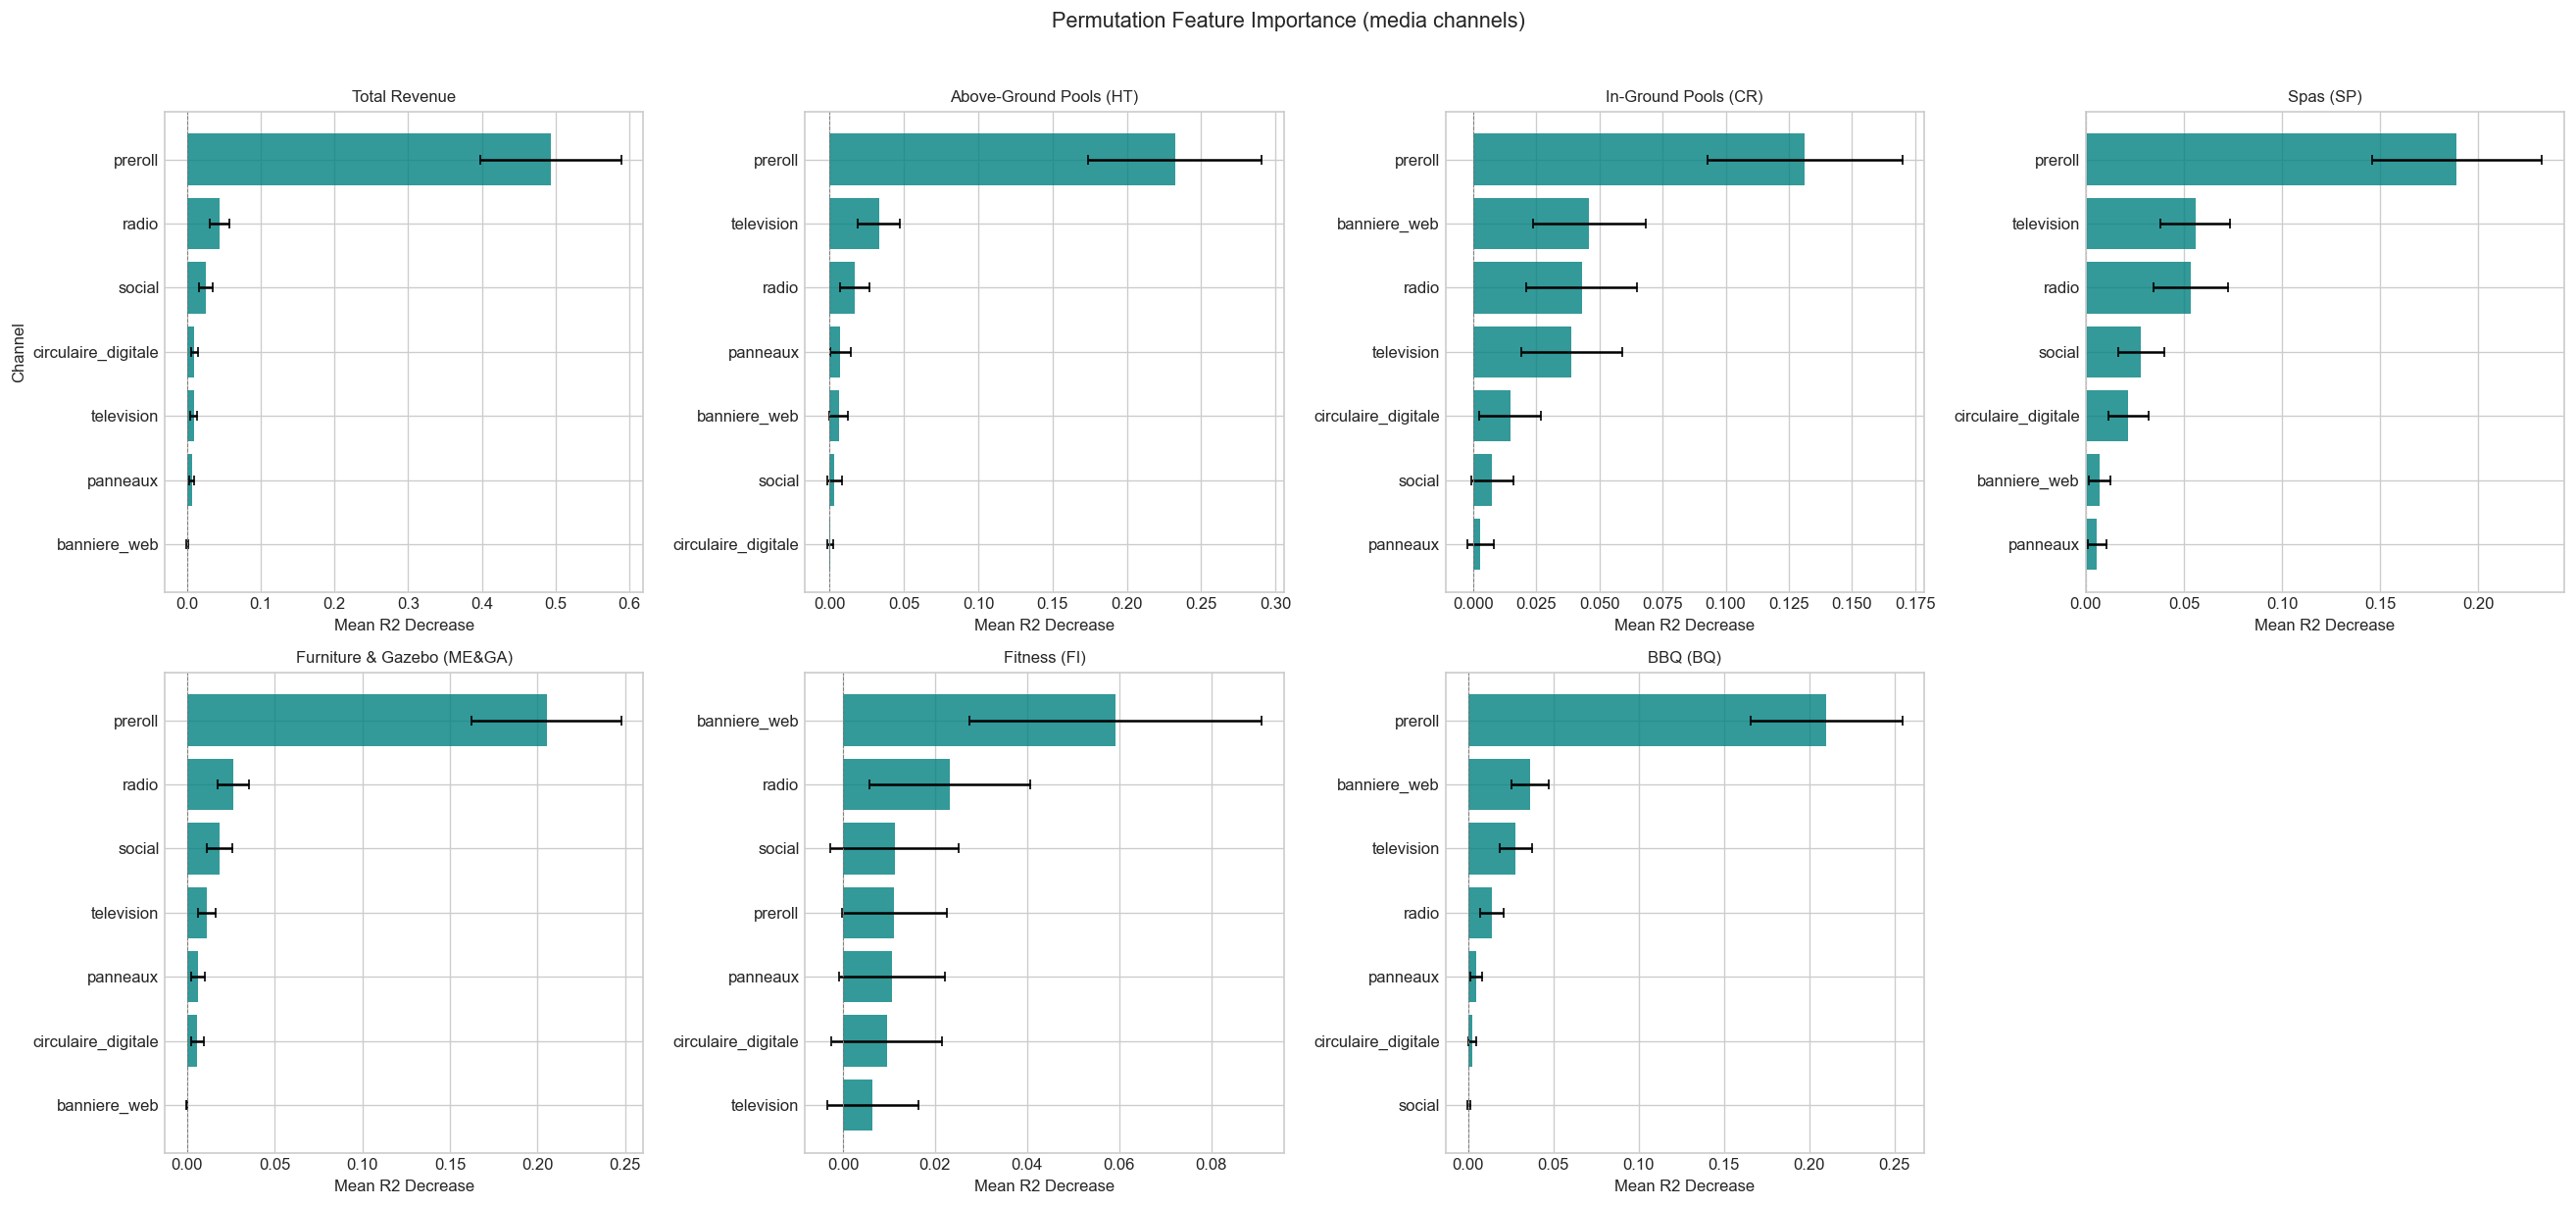

In [27]:
# ===================================================================
# 7-D  PERMUTATION FEATURE IMPORTANCE (2x4 grid)
# ===================================================================
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    model = ridge_results[target]['model']
    y = df[target].values

    perm = permutation_importance(model, X_scaled, y, n_repeats=100,
                                  random_state=42, scoring='r2')
    perm_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'importance_mean': perm.importances_mean,
        'importance_std':  perm.importances_std,
    }).sort_values('importance_mean', ascending=True)

    perm_media = perm_df[perm_df['feature'].str.contains('_saturated')].copy()
    perm_media['label'] = perm_media['feature'].str.replace('media_', '').str.replace('_saturated', '')

    ax.barh(perm_media['label'], perm_media['importance_mean'], alpha=0.8, color='teal')
    ax.errorbar(perm_media['importance_mean'], perm_media['label'],
                xerr=perm_media['importance_std'],
                fmt='none', ecolor='black', capsize=3)
    ax.set_xlabel('Mean R2 Decrease')
    ax.set_title(f'{PRODUCT_LABELS[target]}', fontsize=10)
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.6)

fig.delaxes(axes[-1])
axes[0].set_ylabel('Channel')
fig.suptitle('Permutation Feature Importance (media channels)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'causal_permutation_importance.png', dpi=150)
plt.show()

In [28]:
# ===================================================================
# 7-E  ROBUSTNESS SUMMARY (total revenue)
# ===================================================================
target = 'total_all_revenue'
label = PRODUCT_LABELS[target]
robustness_rows = []

for ch in MEDIA_CHANNELS:
    ch_short = ch.replace('media_', '')

    adstock_sub = sens_decay_df[(sens_decay_df['product'] == label) &
                                (sens_decay_df['channel'] == ch_short)]
    adstock_signs = np.sign(adstock_sub['coef'].values)
    adstock_stable = len(set(adstock_signs[adstock_signs != 0])) <= 1

    sat_sub = sens_sat_df[(sens_sat_df['product'] == label) &
                          (sens_sat_df['channel'] == ch_short)]
    sat_signs = np.sign(sat_sub['coef'].values)
    sat_stable = len(set(sat_signs[sat_signs != 0])) <= 1

    loo_sub_v = loo_summary[(loo_summary['product'] == label) &
                            (loo_summary['channel'] == ch_short)]
    base_coef = abs(ridge_results[target]['model'].coef_[
        FEATURE_COLS.index(f'{ch}_saturated')])
    loo_stable = True
    if len(loo_sub_v) > 0 and base_coef > 0:
        loo_stable = loo_sub_v['max_abs_change'].values[0] < 0.5 * base_coef

    bs = boot_summary[target]
    bs_row = bs[bs['feature'] == f'{ch}_saturated'].iloc[0]
    ci_excludes_zero = (bs_row['ci_lower'] > 0) or (bs_row['ci_upper'] < 0)

    robustness_rows.append({
        'Channel':  ch_short,
        'Adstock-stable':    'Yes' if adstock_stable else 'No',
        'Saturation-stable': 'Yes' if sat_stable else 'No',
        'LOO-stable':        'Yes' if loo_stable else 'No',
        'CI-excludes-0':     'Yes' if ci_excludes_zero else 'No',
    })

robust_df = pd.DataFrame(robustness_rows)
print(f'Robustness Summary -- {label}:')
print(robust_df.to_string(index=False))

Robustness Summary -- Total Revenue:
            Channel Adstock-stable Saturation-stable LOO-stable CI-excludes-0
         television            Yes                No         No            No
              radio            Yes               Yes        Yes            No
           panneaux            Yes               Yes         No            No
       social_media            Yes               Yes        Yes            No
            preroll            Yes               Yes        Yes           Yes
       banniere_web            Yes               Yes         No            No
circulaire_digitale            Yes               Yes         No            No


---
## Section 8 — Limitations & Causal Interpretation

### Small-sample caveats
- **N = 36**: With 36 monthly observations and 14 parameters, statistical power is improved but still limited. Ridge shrinkage is essential.
- **Wide confidence intervals** — some channels' CIs cross zero. Absence of significance does not equal absence of effect.

### Identification assumptions
1. **Conditional exogeneity** — after controlling for seasonality and weather, the remaining variation in media spend is unrelated to unobserved demand shocks.
2. **No simultaneity** — revenue causes no immediate spend adjustment within the same month.
3. **Correct functional form** — geometric adstock and Hill saturation are assumed; the true response shape is unknown.
4. **Stable coefficients** — the relationship between spend and revenue is assumed constant across FY2023-FY2025.

### What these results CAN vs CANNOT say
| CAN | CANNOT |
|-----|--------|
| Identify which channels have the strongest *association* with revenue after controlling for seasonality | Prove strict causation without experimental variation |
| Provide directional guidance on channel efficiency | Give precise point estimates (CIs are wide) |
| Flag channels that are likely saturated | Rule out channels whose CIs include zero |
| Compare relative effectiveness across 6 product categories | Estimate individual-level response |

---
## Section 9 — Outputs & Next Steps

### Deliverables
1. **Effectiveness table** — `media_effectiveness_results.csv` (marginal effects per product per channel)
2. **Saturation curves** — `saturation_curves.csv` (spend vs incremental revenue)
3. **Robustness summary** — `robustness_summary.csv`
4. **Model parameters** — `causal_model_params.json`

### How this feeds into budget optimization
- The effectiveness table shows how much additional revenue each $1,000 of spend generates per channel.
- The saturation curves show diminishing returns — where channels are over/under-invested.
- The efficiency frontier shows which channels are over-/under-indexed relative to their contribution.

In [29]:
# ---------- Save outputs ----------

# 1. Effectiveness table
eff_df.to_csv(processed_path / 'media_effectiveness_results.csv', index=False)
print(f'Saved: {processed_path / "media_effectiveness_results.csv"}')

# 2. Saturation curves
sat_curves_df.to_csv(processed_path / 'saturation_curves.csv', index=False)
print(f'Saved: {processed_path / "saturation_curves.csv"}')

# 3. Robustness summary
robust_df.to_csv(processed_path / 'robustness_summary.csv', index=False)
print(f'Saved: {processed_path / "robustness_summary.csv"}')

# 4. Model parameters
model_params = {
    'decay_rates': {k.replace('media_', ''): v for k, v in DECAY_RATES.items()},
    'saturation_params': {k.replace('media_', ''): v for k, v in SATURATION_PARAMS.items()},
    'ridge_alphas': {PRODUCT_LABELS[t]: float(ridge_results[t]['best_alpha']) for t in TARGET_COLS},
    'ridge_r2': {PRODUCT_LABELS[t]: float(ridge_results[t]['r2']) for t in TARGET_COLS},
    'ridge_r2_cv': {PRODUCT_LABELS[t]: float(ridge_results[t]['r2_cv']) for t in TARGET_COLS},
    'feature_cols': FEATURE_COLS,
    'media_channels': [c.replace('media_', '') for c in MEDIA_CHANNELS],
    'target_cols': TARGET_COLS,
}
with open(processed_path / 'causal_model_params.json', 'w') as f:
    json.dump(model_params, f, indent=2, default=str)
print(f'Saved: {processed_path / "causal_model_params.json"}')

Saved: /Users/raoul/Dev/busa693-clubpiscine/data/processed/media_effectiveness_results.csv
Saved: /Users/raoul/Dev/busa693-clubpiscine/data/processed/saturation_curves.csv
Saved: /Users/raoul/Dev/busa693-clubpiscine/data/processed/robustness_summary.csv
Saved: /Users/raoul/Dev/busa693-clubpiscine/data/processed/causal_model_params.json


In [30]:
# ---------- Final summary ----------
print('=' * 72)
print('  NOTEBOOK 06 -- CAUSAL INFERENCE: COMPLETE')
print('=' * 72)
print()
print('Models fitted (Ridge, LOOCV):')
for target in TARGET_COLS:
    r = ridge_results[target]
    print(f'  {PRODUCT_LABELS[target]:30s}  alpha={r["best_alpha"]:>8.2f}  '
          f'R2={r["r2"]:.3f}  LOOCV R2={r["r2_cv"]:.3f}  MAE=${r["mae"]:>12,.0f}')
print()
print('Output files:')
print(f'  data/processed/media_effectiveness_results.csv')
print(f'  data/processed/saturation_curves.csv')
print(f'  data/processed/robustness_summary.csv')
print(f'  data/processed/causal_model_params.json')
print()
print('Figures saved to reports/figures/:')
for f in sorted(figures_path.glob('causal_*.png')):
    print(f'  {f.name}')
print()
print('Key improvement: 36 monthly obs (was 19), revenue target (was quotes),'
      ' fixed LOOCV, 3 weather features, no holidays.')

  NOTEBOOK 06 -- CAUSAL INFERENCE: COMPLETE

Models fitted (Ridge, LOOCV):
  Total Revenue                   alpha=    0.41  R2=0.966  LOOCV R2=0.912  MAE=$   1,368,274
  Above-Ground Pools (HT)         alpha=    6.73  R2=0.854  LOOCV R2=0.733  MAE=$     630,940
  In-Ground Pools (CR)            alpha=   38.54  R2=0.668  LOOCV R2=0.531  MAE=$     301,864
  Spas (SP)                       alpha=    4.23  R2=0.929  LOOCV R2=0.855  MAE=$     419,981
  Furniture & Gazebo (ME&GA)      alpha=    2.10  R2=0.966  LOOCV R2=0.915  MAE=$     692,486
  Fitness (FI)                    alpha=   38.54  R2=0.570  LOOCV R2=0.415  MAE=$      53,196
  BBQ (BQ)                        alpha=    0.93  R2=0.958  LOOCV R2=0.887  MAE=$      55,309

Output files:
  data/processed/media_effectiveness_results.csv
  data/processed/saturation_curves.csv
  data/processed/robustness_summary.csv
  data/processed/causal_model_params.json

Figures saved to reports/figures/:
  causal_confounding_wedge.png
  causal_correl